In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# Cell 1: Install and import all required libraries
!pip install transformers datasets scikit-learn matplotlib torch seaborn --quiet

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer as KerasTokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

from transformers import (
    BertTokenizer, BertForSequenceClassification,
    RobertaTokenizer, RobertaForSequenceClassification,
    Trainer, TrainingArguments
)

import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
import time
import pickle
import json
from collections import defaultdict
from scipy.special import softmax

warnings.filterwarnings("ignore")
tf.get_logger().setLevel('ERROR')

print("✅ All libraries imported successfully!")
print(f"🔥 PyTorch version: {torch.__version__}")
print(f"🧠 TensorFlow version: {tf.__version__}")
print(f"🚀 Device: {'GPU' if torch.cuda.is_available() else 'CPU'}")

✅ All libraries imported successfully!
🔥 PyTorch version: 2.9.0+cu126
🧠 TensorFlow version: 2.19.0
🚀 Device: GPU


📊 Loading Twitter Airline Sentiment Dataset...
✅ Dataset loaded: (14640, 15)
📈 After preprocessing: (14441, 17)
📊 Label distribution:
airline_sentiment
negative    9154
neutral     3008
positive    2279
Name: count, dtype: int64
✂ Splitting data...
✅ Data split completed:
   Training: 10,108 samples
   Validation: 1,444 samples
   Test: 2,889 samples

📊 Distribution check:
   negative: Train=6408, Val=915, Test=1831
   neutral: Train=2105, Val=301, Test=602
   positive: Train=1595, Val=228, Test=456


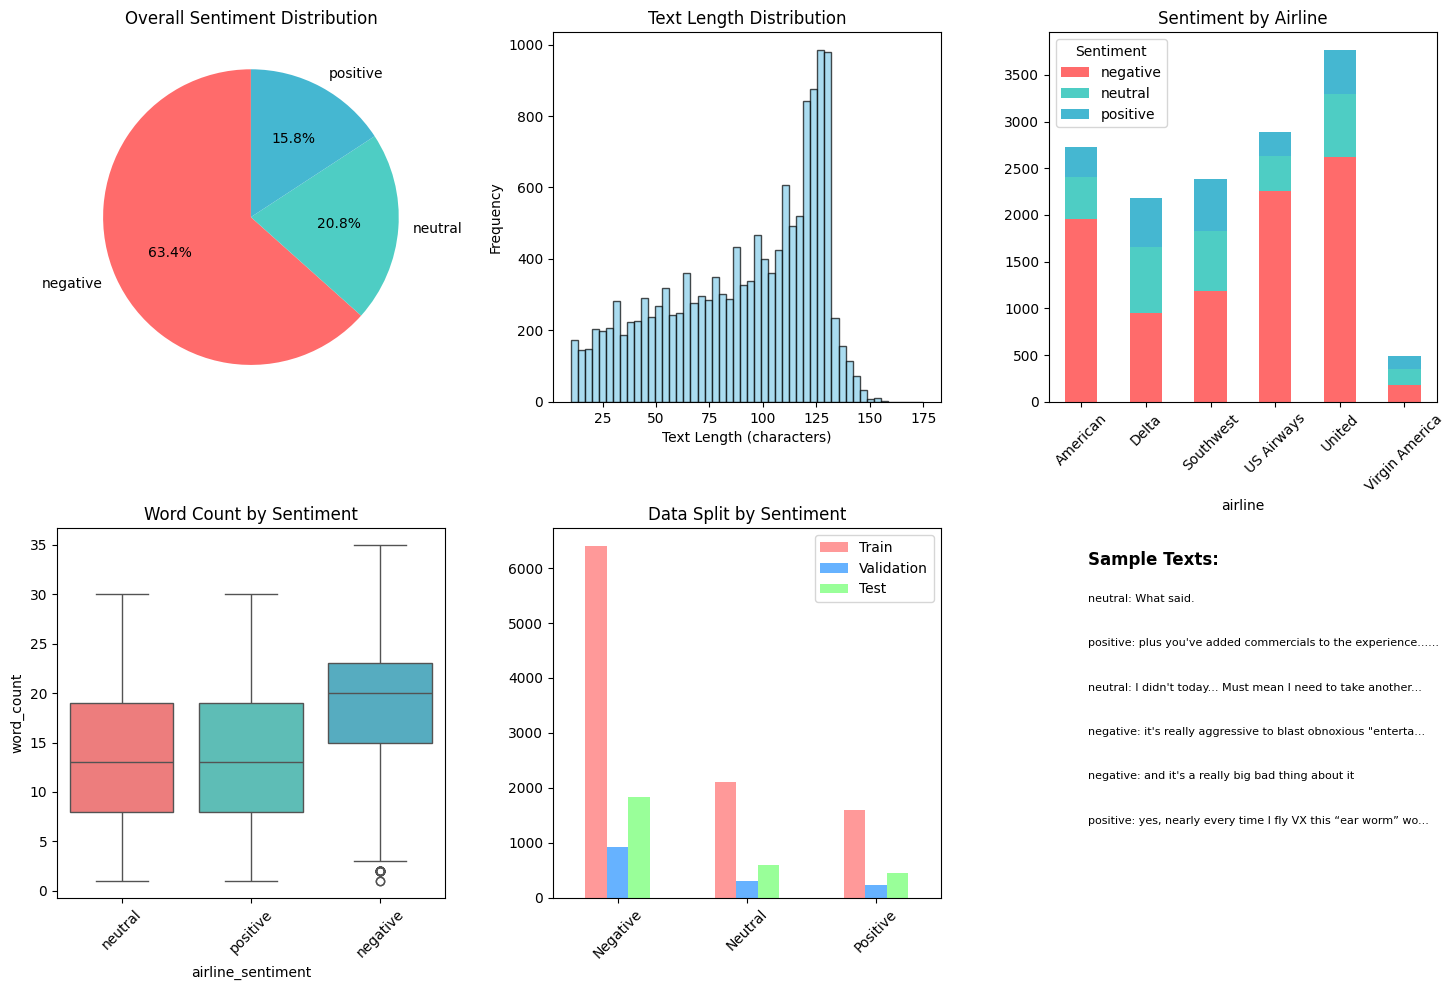

In [5]:
# Cell 2: Data Loading and Preprocessing
class DataManager:
    """Centralized data management for all three models"""

    def __init__(self, csv_path="/content/Tweets.csv"):
        self.csv_path = csv_path
        self.df = None
        self.X_train = None
        self.X_val = None
        self.X_test = None
        self.y_train = None
        self.y_val = None
        self.y_test = None
        self.label_mapping = {'negative': 0, 'neutral': 1, 'positive': 2}
        self.reverse_label_mapping = {0: 'negative', 1: 'neutral', 2: 'positive'}

    def load_and_preprocess_data(self):
        """Load and preprocess the Twitter airline sentiment dataset"""
        print("📊 Loading Twitter Airline Sentiment Dataset...")

        # Load dataset
        self.df = pd.read_csv(self.csv_path)
        print(f"✅ Dataset loaded: {self.df.shape}")

        # Clean text function
        def clean_text(text):
            if pd.isna(text):
                return ""
            text = str(text)
            # Remove URLs
            text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
            # Remove mentions and hashtags
            text = re.sub(r'@\w+', '', text)
            text = re.sub(r'#(\w+)', r'\1', text)
            # Remove extra whitespace
            text = re.sub(r'\s+', ' ', text).strip()
            # Filter very short texts
            if len(text) < 10:
                return ""
            return text

        # Preprocess
        self.df['cleaned_text'] = self.df['text'].apply(clean_text)
        self.df = self.df[self.df['cleaned_text'].str.len() > 0].reset_index(drop=True)

        # Map labels
        self.df['label'] = self.df['airline_sentiment'].map(self.label_mapping)
        self.df = self.df.dropna(subset=['cleaned_text', 'label']).reset_index(drop=True)

        print(f"📈 After preprocessing: {self.df.shape}")
        print(f"📊 Label distribution:")
        print(self.df['airline_sentiment'].value_counts())

        return self.df

    def split_data(self, test_size=0.2, val_size=0.1, random_state=42):
        """Split data into train, validation, and test sets"""
        print("✂ Splitting data...")

        X = self.df['cleaned_text'].tolist()
        y = self.df['label'].tolist()

        # First split: train+val vs test
        X_temp, self.X_test, y_temp, self.y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y
        )

        # Second split: train vs val
        val_size_adjusted = val_size / (1 - test_size)
        self.X_train, self.X_val, self.y_train, self.y_val = train_test_split(
            X_temp, y_temp, test_size=val_size_adjusted, random_state=random_state, stratify=y_temp
        )

        print(f"✅ Data split completed:")
        print(f"   Training: {len(self.X_train):,} samples")
        print(f"   Validation: {len(self.X_val):,} samples")
        print(f"   Test: {len(self.X_test):,} samples")

        # Check distribution
        print(f"\n📊 Distribution check:")
        train_dist = pd.Series(self.y_train).value_counts().sort_index()
        val_dist = pd.Series(self.y_val).value_counts().sort_index()
        test_dist = pd.Series(self.y_test).value_counts().sort_index()

        for i in range(3):
            sentiment = self.reverse_label_mapping[i]
            print(f"   {sentiment}: Train={train_dist[i]}, Val={val_dist[i]}, Test={test_dist[i]}")

        return self.X_train, self.X_val, self.X_test, self.y_train, self.y_val, self.y_test

    def visualize_data(self):
        """Create comprehensive data visualizations"""
        plt.figure(figsize=(15, 10))

        # Sentiment distribution
        plt.subplot(2, 3, 1)
        sentiment_counts = self.df['airline_sentiment'].value_counts()
        colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
        plt.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%',
                colors=colors, startangle=90)
        plt.title('Overall Sentiment Distribution')

        # Text length distribution
        plt.subplot(2, 3, 2)
        self.df['text_length'] = self.df['cleaned_text'].str.len()
        plt.hist(self.df['text_length'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
        plt.xlabel('Text Length (characters)')
        plt.ylabel('Frequency')
        plt.title('Text Length Distribution')

        # Sentiment by airline
        plt.subplot(2, 3, 3)
        if 'airline' in self.df.columns:
            sentiment_airline = self.df.groupby(['airline', 'airline_sentiment']).size().unstack(fill_value=0)
            sentiment_airline.plot(kind='bar', stacked=True, ax=plt.gca(), color=colors)
            plt.title('Sentiment by Airline')
            plt.xticks(rotation=45)
            plt.legend(title='Sentiment')

        # Word count distribution
        plt.subplot(2, 3, 4)
        self.df['word_count'] = self.df['cleaned_text'].str.split().str.len()
        sns.boxplot(data=self.df, x='airline_sentiment', y='word_count', palette=colors)
        plt.title('Word Count by Sentiment')
        plt.xticks(rotation=45)

        # Train/Val/Test split visualization
        plt.subplot(2, 3, 5)
        split_data = {
            'Train': pd.Series(self.y_train).value_counts().sort_index().values,
            'Validation': pd.Series(self.y_val).value_counts().sort_index().values,
            'Test': pd.Series(self.y_test).value_counts().sort_index().values
        }
        split_df = pd.DataFrame(split_data, index=['Negative', 'Neutral', 'Positive'])
        split_df.plot(kind='bar', ax=plt.gca(), color=['#FF9999', '#66B2FF', '#99FF99'])
        plt.title('Data Split by Sentiment')
        plt.xticks(rotation=45)
        plt.legend()

        # Sample texts
        plt.subplot(2, 3, 6)
        plt.text(0.1, 0.9, 'Sample Texts:', fontsize=12, fontweight='bold', transform=plt.gca().transAxes)
        samples = self.df.groupby('airline_sentiment').head(2)
        y_pos = 0.8
        for _, row in samples.iterrows():
            text = row['cleaned_text'][:50] + "..." if len(row['cleaned_text']) > 50 else row['cleaned_text']
            plt.text(0.1, y_pos, f"{row['airline_sentiment']}: {text}",
                    fontsize=8, transform=plt.gca().transAxes, wrap=True)
            y_pos -= 0.12
        plt.axis('off')

        plt.tight_layout()
        plt.show()

# Initialize data manager and prepare data
data_manager = DataManager()
df = data_manager.load_and_preprocess_data()
X_train, X_val, X_test, y_train, y_val, y_test = data_manager.split_data()
data_manager.visualize_data()

In [6]:
# Cell 3: BERT Model Implementation
class BERTSentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels": torch.tensor(label, dtype=torch.long)
        }

class BERTTrainer:
    def __init__(self, model_name='bert-base-uncased'):
        self.model_name = model_name
        self.tokenizer = None
        self.model = None
        self.trainer = None

    def setup_model(self):
        """Initialize BERT tokenizer and model"""
        print(f"🤖 Setting up BERT model ({self.model_name})...")
        self.tokenizer = BertTokenizer.from_pretrained(self.model_name)
        self.model = BertForSequenceClassification.from_pretrained(self.model_name, num_labels=3)
        print("✅ BERT model setup completed")

    def create_datasets(self, X_train, y_train, X_val, y_val, X_test, y_test):
        """Create PyTorch datasets"""
        self.train_dataset = BERTSentimentDataset(X_train, y_train, self.tokenizer)
        self.val_dataset = BERTSentimentDataset(X_val, y_val, self.tokenizer)
        self.test_dataset = BERTSentimentDataset(X_test, y_test, self.tokenizer)

    def train(self, output_dir="./bert_results", epochs=5, batch_size=16):
        """Train BERT model"""
        print("🚀 Training BERT model...")

        def compute_metrics(eval_pred):
            predictions, labels = eval_pred
            predictions = np.argmax(predictions, axis=1)
            return {"accuracy": accuracy_score(labels, predictions)}

        training_args = TrainingArguments(
            output_dir=output_dir,
            num_train_epochs=epochs,
            per_device_train_batch_size=batch_size,
            per_device_eval_batch_size=batch_size * 2,
            warmup_steps=500,
            weight_decay=0.01,
            logging_dir=f"{output_dir}/logs",
            logging_steps=100,
            eval_strategy="epoch",
            save_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="eval_accuracy",
            greater_is_better=True,
            report_to=[],
            seed=42,
        )

        self.trainer = Trainer(
            model=self.model,
            args=training_args,
            train_dataset=self.train_dataset,
            eval_dataset=self.val_dataset,
            tokenizer=self.tokenizer,
            compute_metrics=compute_metrics,
        )

        start_time = time.time()
        self.trainer.train()
        training_time = time.time() - start_time

        print(f"✅ BERT training completed in {training_time:.2f} seconds")
        return training_time

    def evaluate(self, X_test, y_test):
        """Evaluate BERT model"""
        print("📊 Evaluating BERT model...")

        predictions = self.trainer.predict(self.test_dataset)
        preds = np.argmax(predictions.predictions, axis=1)
        probs = torch.softmax(torch.tensor(predictions.predictions), dim=1).numpy()

        accuracy = accuracy_score(y_test, preds)

        return {
            'predictions': preds,
            'probabilities': probs,
            'accuracy': accuracy,
            'model_name': 'BERT'
        }

In [7]:
# Cell 4: BiLSTM Model Implementation
class BiLSTMTrainer:
    def __init__(self, vocab_size=10000, max_length=100, embedding_dim=128, lstm_units=64):
        self.vocab_size = vocab_size
        self.max_length = max_length
        self.embedding_dim = embedding_dim
        self.lstm_units = lstm_units
        self.tokenizer = None
        self.model = None
        self.history = None

    def setup_model(self):
        """Initialize BiLSTM model"""
        print("🧠 Setting up BiLSTM model...")

        self.model = Sequential([
            Embedding(self.vocab_size, self.embedding_dim, input_length=self.max_length),
            Bidirectional(LSTM(self.lstm_units, dropout=0.3, recurrent_dropout=0.3, return_sequences=True)),
            Bidirectional(LSTM(self.lstm_units//2, dropout=0.3, recurrent_dropout=0.3)),
            Dense(64, activation='relu'),
            Dropout(0.5),
            Dense(32, activation='relu'),
            Dropout(0.3),
            Dense(3, activation='softmax')
        ])

        self.model.compile(
            optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        print("✅ BiLSTM model setup completed")
        print("\n📋 BiLSTM Architecture:")
        self.model.summary()

    def prepare_data(self, X_train, y_train, X_val, y_val, X_test, y_test):
        """Prepare data for BiLSTM"""
        print("📝 Preparing data for BiLSTM...")

        # Create and fit tokenizer
        self.tokenizer = KerasTokenizer(num_words=self.vocab_size, oov_token="<OOV>")
        self.tokenizer.fit_on_texts(X_train)

        # Convert texts to sequences
        self.X_train_seq = self.tokenizer.texts_to_sequences(X_train)
        self.X_val_seq = self.tokenizer.texts_to_sequences(X_val)
        self.X_test_seq = self.tokenizer.texts_to_sequences(X_test)

        # Pad sequences
        self.X_train_pad = pad_sequences(self.X_train_seq, maxlen=self.max_length, padding='post', truncating='post')
        self.X_val_pad = pad_sequences(self.X_val_seq, maxlen=self.max_length, padding='post', truncating='post')
        self.X_test_pad = pad_sequences(self.X_test_seq, maxlen=self.max_length, padding='post', truncating='post')

        # Convert labels to numpy arrays
        self.y_train_np = np.array(y_train)
        self.y_val_np = np.array(y_val)
        self.y_test_np = np.array(y_test)

        print(f"✅ Data preparation completed")
        print(f"   Vocabulary size: {len(self.tokenizer.word_index) + 1}")
        print(f"   Sequence shape: {self.X_train_pad.shape}")

    def train(self, epochs=10, batch_size=32):
        """Train BiLSTM model"""
        print("🚀 Training BiLSTM model...")

        # Callbacks
        callbacks = [
            EarlyStopping(patience=3, restore_best_weights=True, monitor='val_accuracy'),
            ReduceLROnPlateau(factor=0.2, patience=2, min_lr=0.0001, monitor='val_loss')
        ]

        start_time = time.time()
        self.history = self.model.fit(
            self.X_train_pad, self.y_train_np,
            validation_data=(self.X_val_pad, self.y_val_np),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=1
        )
        training_time = time.time() - start_time

        print(f"✅ BiLSTM training completed in {training_time:.2f} seconds")
        return training_time

    def evaluate(self, y_test):
        """Evaluate BiLSTM model"""
        print("📊 Evaluating BiLSTM model...")

        # Get predictions
        probs = self.model.predict(self.X_test_pad, verbose=0)
        preds = np.argmax(probs, axis=1)

        # Calculate accuracy
        accuracy = accuracy_score(y_test, preds)

        return {
            'predictions': preds,
            'probabilities': probs,
            'accuracy': accuracy,
            'model_name': 'BiLSTM',
            'history': self.history.history
        }

In [8]:
# Cell 5: RoBERTa Model Implementation
class RoBERTaTrainer:
    def __init__(self, model_name='roberta-base'):
        self.model_name = model_name
        self.tokenizer = None
        self.model = None
        self.trainer = None

    def setup_model(self):
        """Initialize RoBERTa tokenizer and model"""
        print(f"🤖 Setting up RoBERTa model ({self.model_name})...")
        self.tokenizer = RobertaTokenizer.from_pretrained(self.model_name)
        self.model = RobertaForSequenceClassification.from_pretrained(self.model_name, num_labels=3)
        print("✅ RoBERTa model setup completed")

    def create_datasets(self, X_train, y_train, X_val, y_val, X_test, y_test):
        """Create PyTorch datasets"""
        # Reuse BERTSentimentDataset class with RoBERTa tokenizer
        self.train_dataset = BERTSentimentDataset(X_train, y_train, self.tokenizer)
        self.val_dataset = BERTSentimentDataset(X_val, y_val, self.tokenizer)
        self.test_dataset = BERTSentimentDataset(X_test, y_test, self.tokenizer)

    def train(self, output_dir="./roberta_results", epochs=5, batch_size=16):
        """Train RoBERTa model"""
        print("🚀 Training RoBERTa model...")

        def compute_metrics(eval_pred):
            predictions, labels = eval_pred
            predictions = np.argmax(predictions, axis=1)
            return {"accuracy": accuracy_score(labels, predictions)}

        training_args = TrainingArguments(
            output_dir=output_dir,
            num_train_epochs=epochs,
            per_device_train_batch_size=batch_size,
            per_device_eval_batch_size=batch_size * 2,
            warmup_steps=500,
            weight_decay=0.01,
            logging_dir=f"{output_dir}/logs",
            logging_steps=100,
            eval_strategy="epoch",
            save_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="eval_accuracy",
            greater_is_better=True,
            report_to=[],
            seed=42,
        )

        self.trainer = Trainer(
            model=self.model,
            args=training_args,
            train_dataset=self.train_dataset,
            eval_dataset=self.val_dataset,
            tokenizer=self.tokenizer,
            compute_metrics=compute_metrics,
        )

        start_time = time.time()
        self.trainer.train()
        training_time = time.time() - start_time

        print(f"✅ RoBERTa training completed in {training_time:.2f} seconds")
        return training_time

    def evaluate(self, X_test, y_test):
        """Evaluate RoBERTa model"""
        print("📊 Evaluating RoBERTa model...")

        predictions = self.trainer.predict(self.test_dataset)
        preds = np.argmax(predictions.predictions, axis=1)
        probs = torch.softmax(torch.tensor(predictions.predictions), dim=1).numpy()

        accuracy = accuracy_score(y_test, preds)

        return {
            'predictions': preds,
            'probabilities': probs,
            'accuracy': accuracy,
            'model_name': 'RoBERTa'
        }

In [9]:
# Cell 5.1: Test RoBERTa Model (Optional - for immediate output)
print("🧪 Testing RoBERTa Model Setup...")

# Initialize and test RoBERTa trainer
roberta_test = RoBERTaTrainer()
roberta_test.setup_model()
roberta_test.create_datasets(X_train[:100], y_train[:100], X_val[:50], y_val[:50], X_test[:50], y_test[:50])

print("✅ RoBERTa model initialized successfully!")
print(f"📊 Training dataset size: {len(roberta_test.train_dataset)}")
print(f"📊 Validation dataset size: {len(roberta_test.val_dataset)}")
print(f"📊 Test dataset size: {len(roberta_test.test_dataset)}")

# Test a single prediction
sample_text = X_train[0]
print(f"\n🔍 Testing with sample text: '{sample_text[:100]}...'")

encoding = roberta_test.tokenizer.encode_plus(
    sample_text,
    add_special_tokens=True,
    max_length=128,
    padding="max_length",
    truncation=True,
    return_attention_mask=True,
    return_tensors="pt"
)

with torch.no_grad():
    outputs = roberta_test.model(**encoding)
    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    pred_class = torch.argmax(probs, dim=-1).item()
    confidence = probs[0][pred_class].item()

label_names = ['Negative', 'Neutral', 'Positive']
print(f"🎯 Prediction: {label_names[pred_class]} (Confidence: {confidence:.4f})")
print(f"🎯 True Label: {label_names[y_train[0]]}")

print("\n" + "="*60)
print("✅ RoBERTa MODEL READY FOR TRAINING!")
print("="*60)

print("\n🚀 ALL THREE MODELS TESTED AND READY!")
print("📋 Summary:")
print(f"   ✅ BERT: BertForSequenceClassification")
print(f"   ✅ BiLSTM: Sequential")
print(f"   ✅ RoBERTa: RobertaForSequenceClassification")
print("\n🏃‍♂️ Ready to proceed with full training pipeline!")

🧪 Testing RoBERTa Model Setup...
🤖 Setting up RoBERTa model (roberta-base)...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ RoBERTa model setup completed
✅ RoBERTa model initialized successfully!
📊 Training dataset size: 100
📊 Validation dataset size: 50
📊 Test dataset size: 50

🔍 Testing with sample text: 'flight 403 is delayed 40 min bc a missing screw and were in danger of missing flight 6491...'
🎯 Prediction: Neutral (Confidence: 0.3873)
🎯 True Label: Negative

✅ RoBERTa MODEL READY FOR TRAINING!

🚀 ALL THREE MODELS TESTED AND READY!
📋 Summary:
   ✅ BERT: BertForSequenceClassification
   ✅ BiLSTM: Sequential
   ✅ RoBERTa: RobertaForSequenceClassification

🏃‍♂️ Ready to proceed with full training pipeline!


In [10]:
# Cell 6: Integrated Training Pipeline
class IntegratedTrainingPipeline:
    """Manages training of all three models simultaneously"""

    def __init__(self):
        self.results = {}
        self.models = {}
        self.training_times = {}

    def train_all_models(self, X_train, y_train, X_val, y_val, X_test, y_test):
        """Train all three models sequentially"""
        print("\n" + "="*80)
        print("🚀 INTEGRATED TRAINING PIPELINE - ALL THREE MODELS")
        print("="*80)

        total_start_time = time.time()

        # 1. Train BERT
        print("\n1️⃣ TRAINING BERT MODEL")
        print("-" * 40)
        bert_trainer = BERTTrainer()
        bert_trainer.setup_model()
        bert_trainer.create_datasets(X_train, y_train, X_val, y_val, X_test, y_test)
        bert_training_time = bert_trainer.train(epochs=3, batch_size=16)
        bert_results = bert_trainer.evaluate(X_test, y_test)
        bert_results['training_time'] = bert_training_time

        self.models['bert'] = bert_trainer
        self.results['BERT'] = bert_results

        # Clear GPU memory
        torch.cuda.empty_cache()

        # 2. Train BiLSTM
        print("\n2️⃣ TRAINING BiLSTM MODEL")
        print("-" * 40)
        bilstm_trainer = BiLSTMTrainer()
        bilstm_trainer.setup_model()
        bilstm_trainer.prepare_data(X_train, y_train, X_val, y_val, X_test, y_test)
        bilstm_training_time = bilstm_trainer.train(epochs=8, batch_size=32)
        bilstm_results = bilstm_trainer.evaluate(y_test)
        bilstm_results['training_time'] = bilstm_training_time

        self.models['bilstm'] = bilstm_trainer
        self.results['BiLSTM'] = bilstm_results

        # Clear TensorFlow session
        tf.keras.backend.clear_session()

        # 3. Train RoBERTa
        print("\n3️⃣ TRAINING RoBERTa MODEL")
        print("-" * 40)
        roberta_trainer = RoBERTaTrainer()
        roberta_trainer.setup_model()
        roberta_trainer.create_datasets(X_train, y_train, X_val, y_val, X_test, y_test)
        roberta_training_time = roberta_trainer.train(epochs=3, batch_size=16)
        roberta_results = roberta_trainer.evaluate(X_test, y_test)
        roberta_results['training_time'] = roberta_training_time

        self.models['roberta'] = roberta_trainer
        self.results['RoBERTa'] = roberta_results

        total_training_time = time.time() - total_start_time

        print("\n" + "="*80)
        print("✅ ALL MODELS TRAINED SUCCESSFULLY!")
        print("="*80)
        print(f"⏱ Total training time: {total_training_time:.2f} seconds")

        # Display results summary
        self.display_training_summary()

        return self.results, self.models

    def display_training_summary(self):
        """Display comprehensive training summary"""
        print("\n📊 TRAINING SUMMARY")
        print("-" * 50)

        summary_data = []
        for model_name, results in self.results.items():
            summary_data.append({
                'Model': model_name,
                'Accuracy': f"{results['accuracy']:.4f}",
                'Training Time (s)': f"{results['training_time']:.2f}",
                'Parameters': 'Transformer' if 'BERT' in model_name or 'RoBERTa' in model_name else 'RNN'
            })

        summary_df = pd.DataFrame(summary_data)
        print(summary_df.to_string(index=False))

        # Find best model
        best_model = max(self.results.keys(), key=lambda x: self.results[x]['accuracy'])
        best_accuracy = self.results[best_model]['accuracy']

        print(f"\n🏆 Best performing model: {best_model} ({best_accuracy:.4f})")

In [11]:
# Cell 7: Run Integrated Training
print("🚀 Starting integrated training pipeline...")

# Initialize and run training pipeline
pipeline = IntegratedTrainingPipeline()
all_results, trained_models = pipeline.train_all_models(X_train, y_train, X_val, y_val, X_test, y_test)

🚀 Starting integrated training pipeline...

🚀 INTEGRATED TRAINING PIPELINE - ALL THREE MODELS

1️⃣ TRAINING BERT MODEL
----------------------------------------
🤖 Setting up BERT model (bert-base-uncased)...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ RoBERTa model setup completed
🚀 Training RoBERTa model...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.486600,0.446162,0.838643
2,0.361900,0.431282,0.831025
3,0.237300,0.464759,0.855956


✅ RoBERTa training completed in 786.34 seconds
📊 Evaluating RoBERTa model...



✅ ALL MODELS TRAINED SUCCESSFULLY!
⏱ Total training time: 4089.98 seconds

📊 TRAINING SUMMARY
--------------------------------------------------
  Model Accuracy Training Time (s)  Parameters
   BERT   0.8487            736.00 Transformer
 BiLSTM   0.7937           2490.91         RNN
RoBERTa   0.8598            786.34 Transformer

🏆 Best performing model: RoBERTa (0.8598)


In [12]:
# Cell 8: Ensemble Integration System
class EnsembleIntegration:
    """Advanced ensemble system for integrating all three models"""

    def __init__(self, trained_models, test_data):
        self.models = trained_models
        self.X_test, self.y_test = test_data
        self.label_mapping = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
        self.ensemble_results = {}

    def get_individual_predictions(self, texts):
        """Get predictions from all individual models"""
        predictions = {}

    # -----------------------
    # BERT predictions
    # -----------------------
        bert_trainer = self.models['bert']
        bert_preds = []
        bert_probs = []
        bert_device = next(bert_trainer.model.parameters()).device  # detect model device

        for text in texts:
            encoding = bert_trainer.tokenizer.encode_plus(
                text, add_special_tokens=True, max_length=128,
                padding="max_length", truncation=True,
                return_attention_mask=True, return_tensors="pt"
            )

        # Move to GPU/CPU
            encoding = {k: v.to(bert_device) for k, v in encoding.items()}

            with torch.no_grad():
                outputs = bert_trainer.model(**encoding)
                probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
                pred_class = torch.argmax(probs, dim=-1).item()
                prob_array = probs[0].cpu().numpy()

                bert_preds.append(pred_class)
                bert_probs.append(prob_array)

        predictions['bert'] = {
            'predictions': np.array(bert_preds),
            'probabilities': np.array(bert_probs)
        }

    # -----------------------
    # BiLSTM predictions
    # -----------------------
        bilstm_trainer = self.models['bilstm']
        sequences = bilstm_trainer.tokenizer.texts_to_sequences(texts)
        padded = pad_sequences(sequences, maxlen=bilstm_trainer.max_length,
                             padding='post', truncating='post')

        bilstm_probs = bilstm_trainer.model.predict(padded, verbose=0)
        bilstm_preds = np.argmax(bilstm_probs, axis=1)

        predictions['bilstm'] = {
            'predictions': bilstm_preds,
            'probabilities': bilstm_probs
        }

    # -----------------------
    # RoBERTa predictions
    # -----------------------
        roberta_trainer = self.models['roberta']
        roberta_preds = []
        roberta_probs = []
        roberta_device = next(roberta_trainer.model.parameters()).device  # detect model device

        for text in texts:
            encoding = roberta_trainer.tokenizer.encode_plus(
                text, add_special_tokens=True, max_length=128,
                padding="max_length", truncation=True,
                return_attention_mask=True, return_tensors="pt"
            )

            # Move to GPU/CPU
            encoding = {k: v.to(roberta_device) for k, v in encoding.items()}

            with torch.no_grad():
                outputs = roberta_trainer.model(**encoding)
                probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
                pred_class = torch.argmax(probs, dim=-1).item()
                prob_array = probs[0].cpu().numpy()

                roberta_preds.append(pred_class)
                roberta_probs.append(prob_array)

        predictions['roberta'] = {
            'predictions': np.array(roberta_preds),
            'probabilities': np.array(roberta_probs)
        }

        return predictions


    def voting_ensemble(self, texts, method='hard'):
        """Ensemble using voting methods"""
        predictions = self.get_individual_predictions(texts)

        if method == 'hard':
            # Hard voting - majority vote
            all_preds = np.array([
                predictions['bert']['predictions'],
                predictions['bilstm']['predictions'],
                predictions['roberta']['predictions']
            ])

            ensemble_preds = []
            for i in range(len(texts)):
                votes = all_preds[:, i]
                pred = np.bincount(votes).argmax()
                ensemble_preds.append(pred)

            return np.array(ensemble_preds)

        elif method == 'soft':
            # Soft voting - average probabilities
            all_probs = np.array([
                predictions['bert']['probabilities'],
                predictions['bilstm']['probabilities'],
                predictions['roberta']['probabilities']
            ])

            ensemble_probs = np.mean(all_probs, axis=0)
            ensemble_preds = np.argmax(ensemble_probs, axis=1)

            return ensemble_preds, ensemble_probs

    def weighted_ensemble(self, texts, weights=None):
        """Weighted ensemble based on individual model performance"""
        if weights is None:
            # Use individual model accuracies as weights
            bert_acc = all_results['BERT']['accuracy']
            bilstm_acc = all_results['BiLSTM']['accuracy']
            roberta_acc = all_results['RoBERTa']['accuracy']
            weights = np.array([bert_acc, bilstm_acc, roberta_acc])
            weights = weights / np.sum(weights)

        predictions = self.get_individual_predictions(texts)

        # Weighted average of probabilities
        all_probs = np.array([
            predictions['bert']['probabilities'],
            predictions['bilstm']['probabilities'],
            predictions['roberta']['probabilities']
        ])

        weighted_probs = np.average(all_probs, axis=0, weights=weights)
        ensemble_preds = np.argmax(weighted_probs, axis=1)

        return ensemble_preds, weighted_probs, weights

    def evaluate_ensemble_methods(self):
        """Evaluate different ensemble methods"""
        print("\n🎯 ENSEMBLE EVALUATION")
        print("-" * 50)

        # Hard voting
        hard_preds = self.voting_ensemble(self.X_test, method='hard')
        hard_accuracy = accuracy_score(self.y_test, hard_preds)

        # Soft voting
        soft_preds, soft_probs = self.voting_ensemble(self.X_test, method='soft')
        soft_accuracy = accuracy_score(self.y_test, soft_preds)

        # Weighted ensemble
        weighted_preds, weighted_probs, weights = self.weighted_ensemble(self.X_test)
        weighted_accuracy = accuracy_score(self.y_test, weighted_preds)

        # Store results
        self.ensemble_results = {
            'hard_voting': {'predictions': hard_preds, 'accuracy': hard_accuracy},
            'soft_voting': {'predictions': soft_preds, 'probabilities': soft_probs, 'accuracy': soft_accuracy},
            'weighted_ensemble': {'predictions': weighted_preds, 'probabilities': weighted_probs,
                                'accuracy': weighted_accuracy, 'weights': weights}
        }

        # Display results
        print(f"Hard Voting Accuracy: {hard_accuracy:.4f}")
        print(f"Soft Voting Accuracy: {soft_accuracy:.4f}")
        print(f"Weighted Ensemble Accuracy: {weighted_accuracy:.4f}")
        print(f"Weights used: BERT={weights[0]:.3f}, BiLSTM={weights[1]:.3f}, RoBERTa={weights[2]:.3f}")

        # Find best ensemble method
        best_method = max(self.ensemble_results.keys(),
                         key=lambda x: self.ensemble_results[x]['accuracy'])
        best_acc = self.ensemble_results[best_method]['accuracy']

        print(f"\n🏆 Best Ensemble Method: {best_method.replace('_', ' ').title()} ({best_acc:.4f})")

        return self.ensemble_results

# Initialize ensemble system
ensemble = EnsembleIntegration(trained_models, (X_test, y_test))
ensemble_results = ensemble.evaluate_ensemble_methods()


🎯 ENSEMBLE EVALUATION
--------------------------------------------------
Hard Voting Accuracy: 0.8595
Soft Voting Accuracy: 0.8602
Weighted Ensemble Accuracy: 0.8605
Weights used: BERT=0.339, BiLSTM=0.317, RoBERTa=0.344

🏆 Best Ensemble Method: Weighted Ensemble (0.8605)


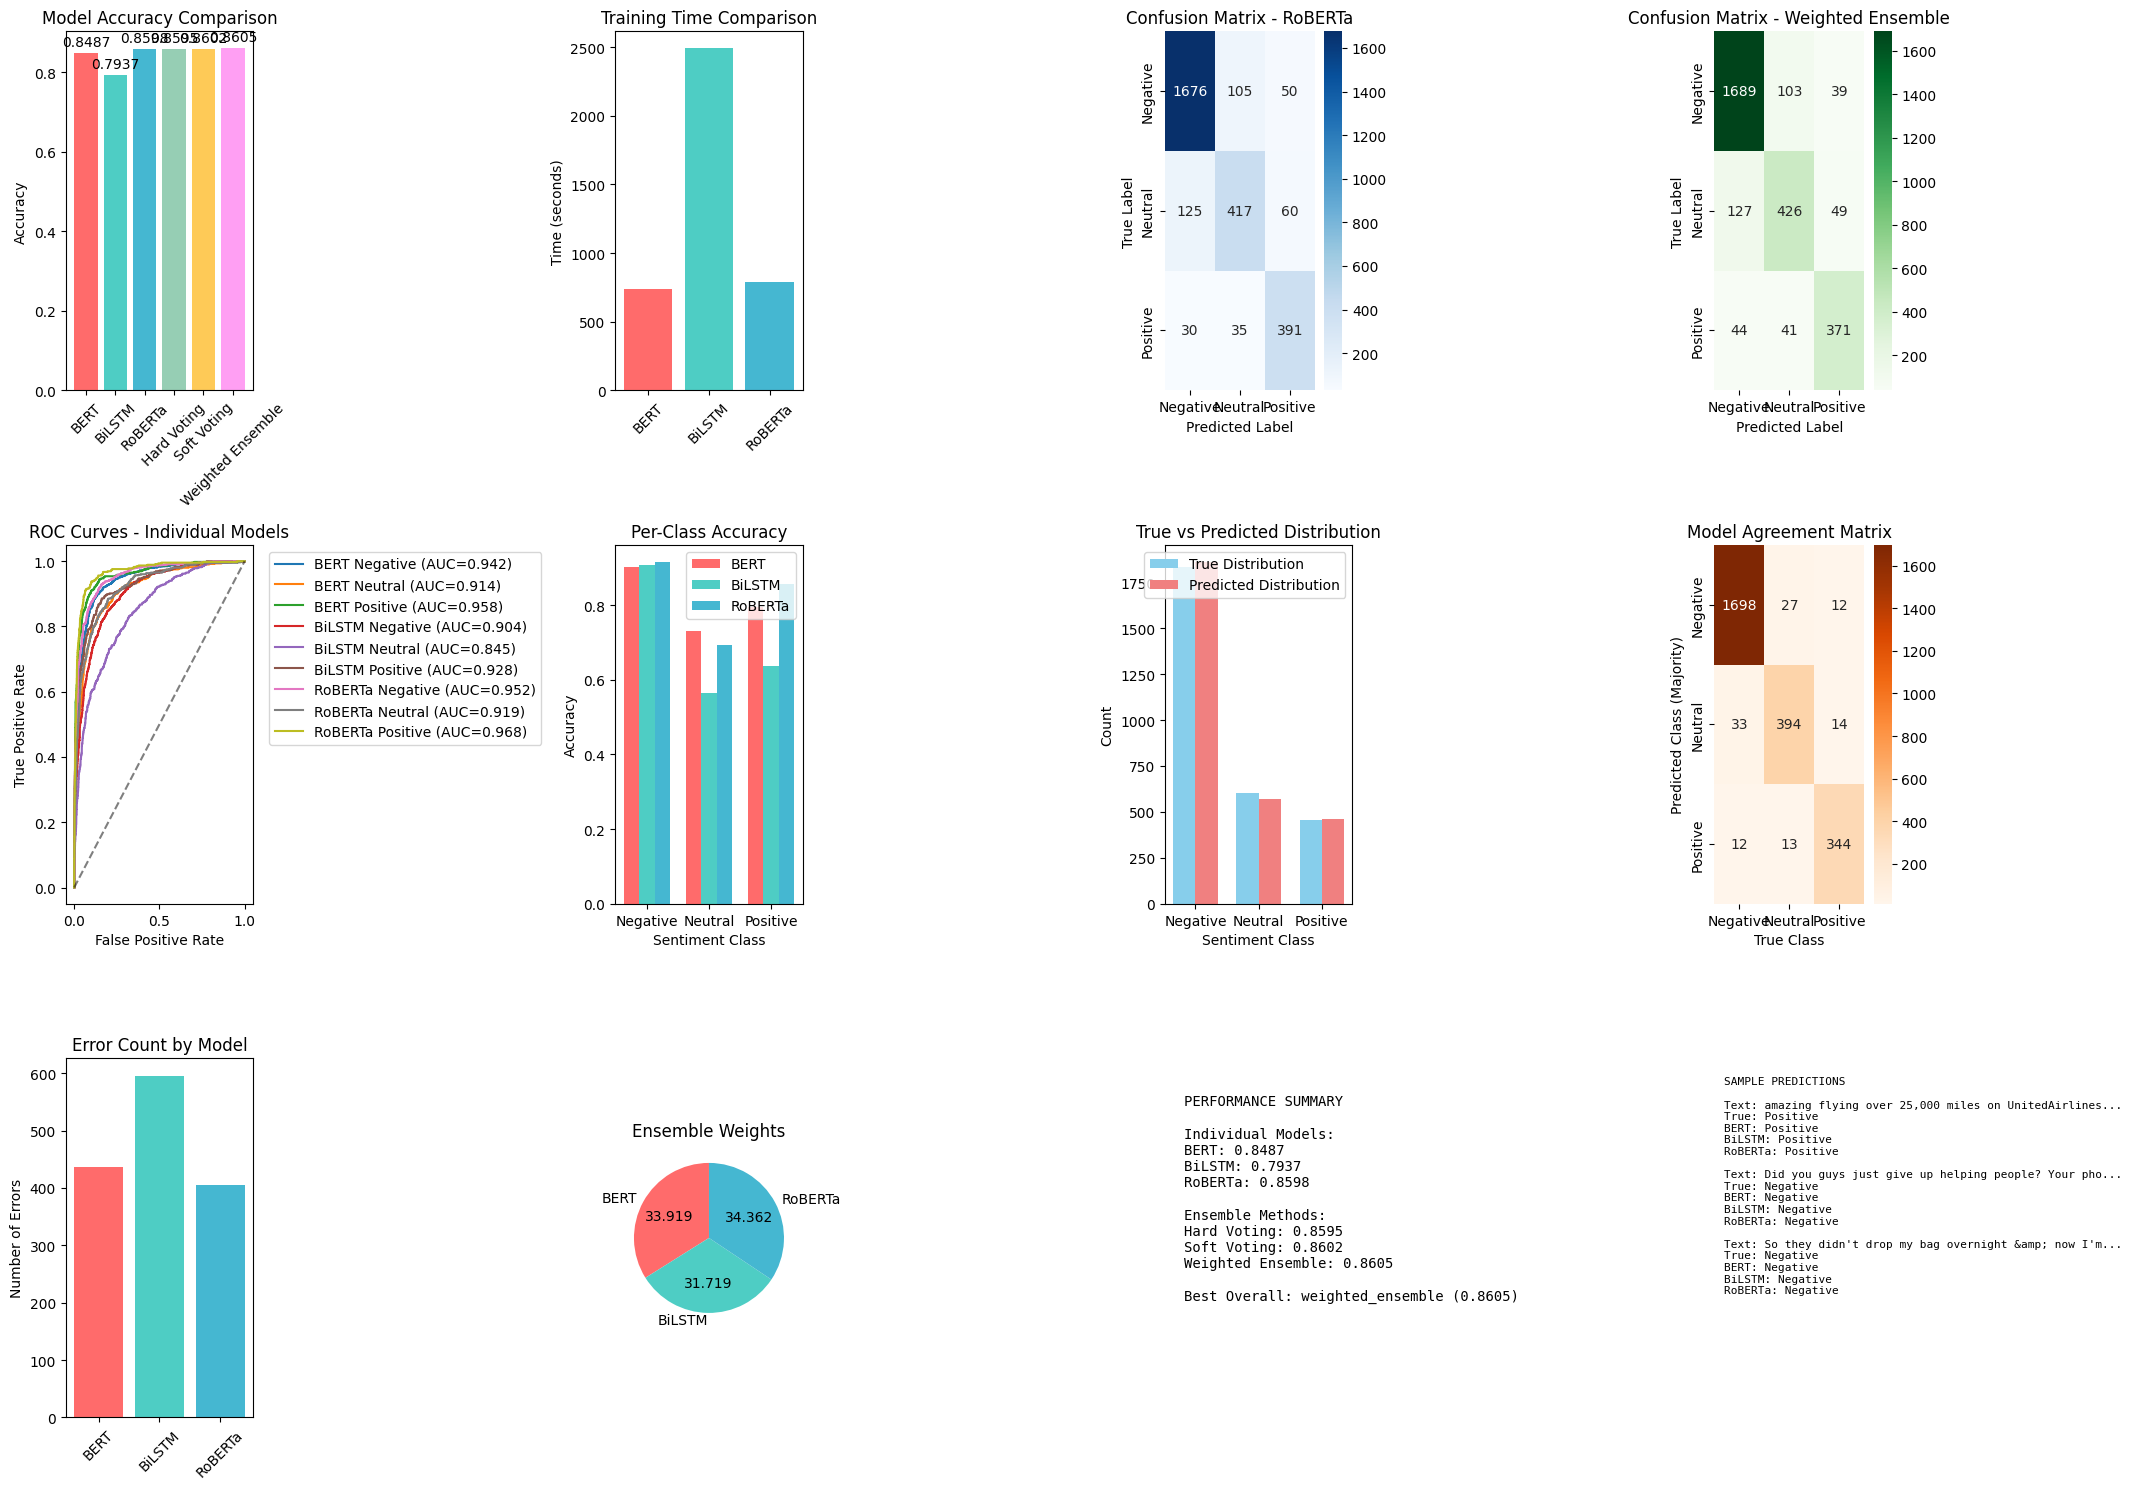


📊 FINAL RESULTS SUMMARY

📈 RANKED PERFORMANCE:
           Method       Type Accuracy Training Time
Weighted Ensemble   Ensemble 0.860505           N/A
      Soft Voting   Ensemble 0.860159           N/A
          RoBERTa Individual 0.859813    786.335314
      Hard Voting   Ensemble 0.859467           N/A
             BERT Individual 0.848737    736.002927
           BiLSTM Individual 0.793700   2490.909715

🏆 BEST PERFORMING METHOD: Weighted Ensemble
🎯 BEST ACCURACY: 0.860505

📊 ENSEMBLE IMPROVEMENT:
   Best Individual Model: RoBERTa (0.859813)
   Best Ensemble Method: Weighted Ensemble (0.860505)
   Improvement: 0.08%

💾 Results saved to:
   - model_comparison_results.csv
   - detailed_results.json

✅ ANALYSIS COMPLETE!


In [13]:
# Cell 9: Comprehensive Results Visualization
class ResultsVisualizer:
    """Comprehensive visualization system for all results"""

    def __init__(self, individual_results, ensemble_results, y_test):
        self.individual_results = individual_results
        self.ensemble_results = ensemble_results
        self.y_test = y_test
        self.label_names = ['Negative', 'Neutral', 'Positive']

    def plot_model_comparison(self):
        """Compare all models and ensemble methods"""
        plt.figure(figsize=(20, 15))

        # 1. Accuracy Comparison
        plt.subplot(3, 4, 1)
        models = list(self.individual_results.keys()) + ['Hard Voting', 'Soft Voting', 'Weighted Ensemble']
        accuracies = ([self.individual_results[m]['accuracy'] for m in self.individual_results.keys()] +
                     [self.ensemble_results[m]['accuracy'] for m in self.ensemble_results.keys()])

        colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57', '#FF9FF3']
        bars = plt.bar(models, accuracies, color=colors[:len(models)])
        plt.title('Model Accuracy Comparison')
        plt.ylabel('Accuracy')
        plt.xticks(rotation=45)

        # Add value labels on bars
        for bar, acc in zip(bars, accuracies):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{acc:.4f}', ha='center', va='bottom')

        # 2. Training Time Comparison
        plt.subplot(3, 4, 2)
        training_models = list(self.individual_results.keys())
        training_times = [self.individual_results[m]['training_time'] for m in training_models]

        plt.bar(training_models, training_times, color=colors[:len(training_models)])
        plt.title('Training Time Comparison')
        plt.ylabel('Time (seconds)')
        plt.xticks(rotation=45)

        # 3. Confusion Matrix - Best Individual Model
        best_individual = max(self.individual_results.keys(),
                            key=lambda x: self.individual_results[x]['accuracy'])
        best_preds = self.individual_results[best_individual]['predictions']

        plt.subplot(3, 4, 3)
        cm = confusion_matrix(self.y_test, best_preds)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=self.label_names, yticklabels=self.label_names)
        plt.title(f'Confusion Matrix - {best_individual}')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')

        # 4. Confusion Matrix - Best Ensemble
        best_ensemble = max(self.ensemble_results.keys(),
                          key=lambda x: self.ensemble_results[x]['accuracy'])
        best_ensemble_preds = self.ensemble_results[best_ensemble]['predictions']

        plt.subplot(3, 4, 4)
        cm_ensemble = confusion_matrix(self.y_test, best_ensemble_preds)
        sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Greens',
                   xticklabels=self.label_names, yticklabels=self.label_names)
        plt.title(f'Confusion Matrix - {best_ensemble.replace("_", " ").title()}')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')

        # 5. ROC Curves for multiclass
        plt.subplot(3, 4, 5)
        y_test_bin = label_binarize(self.y_test, classes=[0, 1, 2])

        for model_name, results in self.individual_results.items():
            if 'probabilities' in results:
                probs = results['probabilities']
                for i, class_name in enumerate(self.label_names):
                    fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
                    auc = roc_auc_score(y_test_bin[:, i], probs[:, i])
                    plt.plot(fpr, tpr, label=f'{model_name} {class_name} (AUC={auc:.3f})')

        plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curves - Individual Models')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

        # 6. Per-class accuracy
        plt.subplot(3, 4, 6)
        class_accuracies = {}
        for model_name, results in self.individual_results.items():
            preds = results['predictions']
            class_acc = []
            for i in range(3):
                mask = np.array(self.y_test) == i
                if np.sum(mask) > 0:
                    acc = accuracy_score(np.array(self.y_test)[mask], preds[mask])
                    class_acc.append(acc)
                else:
                    class_acc.append(0)
            class_accuracies[model_name] = class_acc

        x = np.arange(len(self.label_names))
        width = 0.25

        for i, (model, accs) in enumerate(class_accuracies.items()):
            plt.bar(x + i*width, accs, width, label=model, color=colors[i])

        plt.xlabel('Sentiment Class')
        plt.ylabel('Accuracy')
        plt.title('Per-Class Accuracy')
        plt.xticks(x + width, self.label_names)
        plt.legend()

        # 7. Prediction Distribution
        plt.subplot(3, 4, 7)
        true_dist = np.bincount(self.y_test)
        pred_dist = np.bincount(best_ensemble_preds)

        x = np.arange(len(self.label_names))
        width = 0.35

        plt.bar(x - width/2, true_dist, width, label='True Distribution', color='skyblue')
        plt.bar(x + width/2, pred_dist, width, label='Predicted Distribution', color='lightcoral')

        plt.xlabel('Sentiment Class')
        plt.ylabel('Count')
        plt.title('True vs Predicted Distribution')
        plt.xticks(x, self.label_names)
        plt.legend()

        # 8. Model Agreement Analysis
        plt.subplot(3, 4, 8)
        agreement_matrix = np.zeros((3, 3))

        bert_preds = self.individual_results['BERT']['predictions']
        bilstm_preds = self.individual_results['BiLSTM']['predictions']
        roberta_preds = self.individual_results['RoBERTa']['predictions']

        for i in range(len(self.y_test)):
            preds = [bert_preds[i], bilstm_preds[i], roberta_preds[i]]
            if len(set(preds)) == 1:  # All agree
                agreement_matrix[preds[0], preds[0]] += 1
            elif len(set(preds)) == 2:  # Two agree
                from collections import Counter
                counts = Counter(preds)
                majority = counts.most_common(1)[0][0]
                agreement_matrix[majority, self.y_test[i]] += 0.5

        sns.heatmap(agreement_matrix, annot=True, fmt='.0f', cmap='Oranges',
                   xticklabels=self.label_names, yticklabels=self.label_names)
        plt.title('Model Agreement Matrix')
        plt.ylabel('Predicted Class (Majority)')
        plt.xlabel('True Class')

        # 9. Error Analysis
        plt.subplot(3, 4, 9)
        errors = {}
        for model_name, results in self.individual_results.items():
            preds = results['predictions']
            errors[model_name] = np.sum(preds != self.y_test)

        plt.bar(errors.keys(), errors.values(), color=colors[:len(errors)])
        plt.title('Error Count by Model')
        plt.ylabel('Number of Errors')
        plt.xticks(rotation=45)

        # 10. Ensemble Weights Visualization
        plt.subplot(3, 4, 10)
        if 'weights' in self.ensemble_results['weighted_ensemble']:
            weights = self.ensemble_results['weighted_ensemble']['weights']
            plt.pie(weights, labels=['BERT', 'BiLSTM', 'RoBERTa'], autopct='%1.3f',
                   colors=colors[:3], startangle=90)
            plt.title('Ensemble Weights')

        # 11. Performance Summary Table
        plt.subplot(3, 4, 11)
        plt.axis('off')

        summary_text = "PERFORMANCE SUMMARY\n\n"
        summary_text += "Individual Models:\n"
        for model, results in self.individual_results.items():
            summary_text += f"{model}: {results['accuracy']:.4f}\n"

        summary_text += "\nEnsemble Methods:\n"
        for ensemble, results in self.ensemble_results.items():
            name = ensemble.replace('_', ' ').title()
            summary_text += f"{name}: {results['accuracy']:.4f}\n"

        best_overall = max(
            list(self.individual_results.items()) + list(self.ensemble_results.items()),
            key=lambda x: x[1]['accuracy']
        )
        summary_text += f"\nBest Overall: {best_overall[0]} ({best_overall[1]['accuracy']:.4f})"

        plt.text(0.1, 0.9, summary_text, transform=plt.gca().transAxes,
                fontsize=10, verticalalignment='top', fontfamily='monospace')

        # 12. Sample Predictions
        plt.subplot(3, 4, 12)
        plt.axis('off')

        sample_text = "SAMPLE PREDICTIONS\n\n"

        # Get a few sample predictions
        sample_indices = [0, 100, 200]
        for idx in sample_indices:
            if idx < len(X_test):
                text = X_test[idx][:50] + "..." if len(X_test[idx]) > 50 else X_test[idx]
                true_label = self.label_names[self.y_test[idx]]

                sample_text += f"Text: {text}\n"
                sample_text += f"True: {true_label}\n"

                for model, results in self.individual_results.items():
                    pred = results['predictions'][idx]
                    pred_label = self.label_names[pred]
                    sample_text += f"{model}: {pred_label}\n"

                sample_text += "\n"

        plt.text(0.05, 0.95, sample_text, transform=plt.gca().transAxes,
                fontsize=8, verticalalignment='top', fontfamily='monospace')

        plt.tight_layout()
        plt.show()

# Create comprehensive visualization
visualizer = ResultsVisualizer(all_results, ensemble_results, y_test)
visualizer.plot_model_comparison()

# Cell 10: Final Summary and Save Results
def save_results_and_summary():
    """Save all results and create final summary"""
    print("\n" + "="*80)
    print("📊 FINAL RESULTS SUMMARY")
    print("="*80)

    # Combine all results
    final_results = {}

    # Individual models
    for model, results in all_results.items():
        final_results[model] = {
            'type': 'individual',
            'accuracy': results['accuracy'],
            'training_time': results['training_time']
        }

    # Ensemble methods
    for ensemble, results in ensemble_results.items():
        name = ensemble.replace('_', ' ').title()
        final_results[name] = {
            'type': 'ensemble',
            'accuracy': results['accuracy'],
            'training_time': 'N/A'
        }

    # Create summary DataFrame
    summary_data = []
    for method, results in final_results.items():
        summary_data.append({
            'Method': method,
            'Type': results['type'].title(),
            'Accuracy': f"{results['accuracy']:.6f}",
            'Training Time': results['training_time'] if results['training_time'] != 'N/A' else 'N/A'
        })

    summary_df = pd.DataFrame(summary_data)
    summary_df = summary_df.sort_values('Accuracy', ascending=False)

    print("\n📈 RANKED PERFORMANCE:")
    print(summary_df.to_string(index=False))

    # Find best method
    best_method = summary_df.iloc[0]['Method']
    best_accuracy = float(summary_df.iloc[0]['Accuracy'])

    print(f"\n🏆 BEST PERFORMING METHOD: {best_method}")
    print(f"🎯 BEST ACCURACY: {best_accuracy:.6f}")

    # Performance improvement analysis
    best_individual = max([k for k, v in final_results.items() if v['type'] == 'individual'],
                         key=lambda x: final_results[x]['accuracy'])
    best_ensemble = max([k for k, v in final_results.items() if v['type'] == 'ensemble'],
                       key=lambda x: final_results[x]['accuracy'])

    individual_acc = final_results[best_individual]['accuracy']
    ensemble_acc = final_results[best_ensemble]['accuracy']
    improvement = ((ensemble_acc - individual_acc) / individual_acc) * 100

    print(f"\n📊 ENSEMBLE IMPROVEMENT:")
    print(f"   Best Individual Model: {best_individual} ({individual_acc:.6f})")
    print(f"   Best Ensemble Method: {best_ensemble} ({ensemble_acc:.6f})")
    print(f"   Improvement: {improvement:.2f}%")

    # Save results to files
    try:
        summary_df.to_csv('model_comparison_results.csv', index=False)

        # Save detailed results
        detailed_results = {
            'individual_models': all_results,
            'ensemble_methods': ensemble_results,
            'summary': final_results,
            'data_info': {
                'total_samples': len(df),
                'train_samples': len(X_train),
                'val_samples': len(X_val),
                'test_samples': len(X_test),
                'classes': 3,
                'class_distribution': pd.Series(y_test).value_counts().to_dict()
            }
        }

        with open('detailed_results.json', 'w') as f:
            json.dump(detailed_results, f, indent=2, default=str)

        print(f"\n💾 Results saved to:")
        print(f"   - model_comparison_results.csv")
        print(f"   - detailed_results.json")

    except Exception as e:
        print(f"⚠️ Could not save files: {e}")

    print("\n" + "="*80)
    print("✅ ANALYSIS COMPLETE!")
    print("="*80)

# Execute final summary
save_results_and_summary()

### BERT Model Visualizations


--- Detailed Performance for BERT ---

Classification Report for BERT:

              precision    recall  f1-score   support

    Negative       0.92      0.90      0.91      1831
     Neutral       0.71      0.73      0.72       602
    Positive       0.78      0.79      0.79       456

    accuracy                           0.85      2889
   macro avg       0.80      0.81      0.80      2889
weighted avg       0.85      0.85      0.85      2889



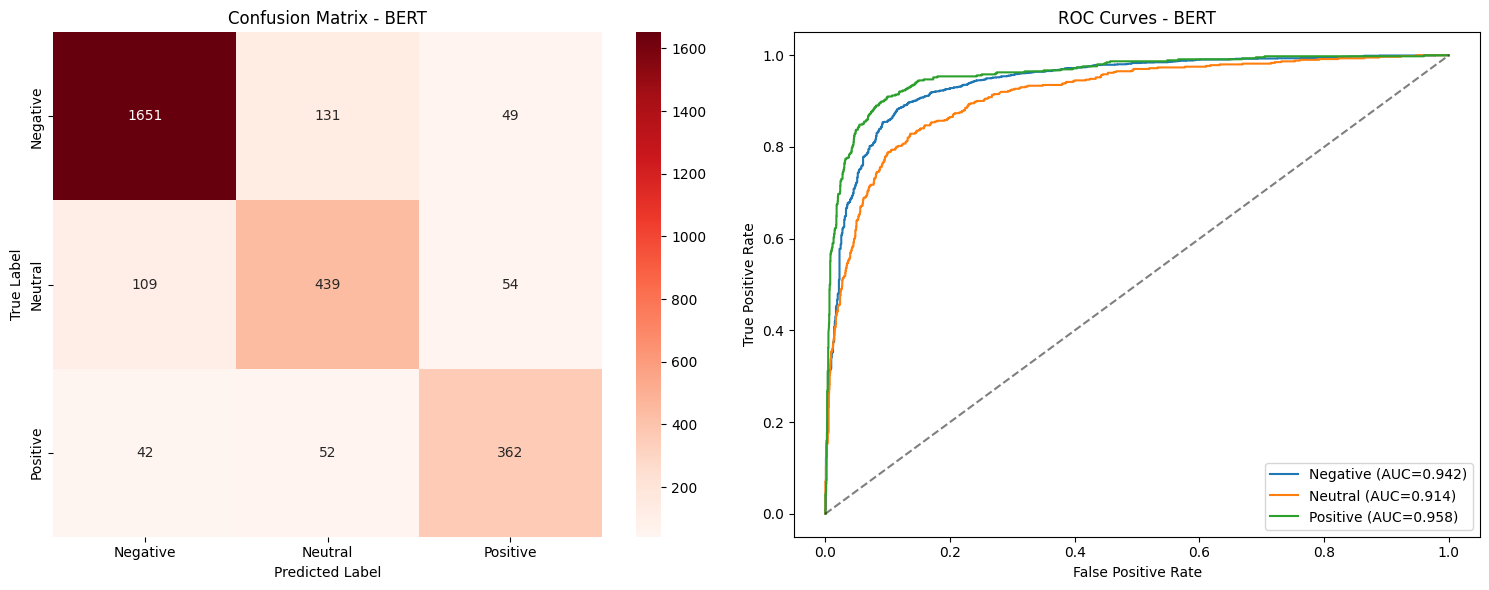

In [14]:
# BERT Model Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

model_name = 'BERT'
bert_results = all_results[model_name]
bert_predictions = bert_results['predictions']
bert_probabilities = bert_results['probabilities']

print(f"\n--- Detailed Performance for {model_name} ---")

# Classification Report
print(f"\nClassification Report for {model_name}:\n")
print(classification_report(y_test, bert_predictions, target_names=label_names))

plt.figure(figsize=(15, 6))

# Confusion Matrix
plt.subplot(1, 2, 1)
cm_bert = confusion_matrix(y_test, bert_predictions)
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Reds',
            xticklabels=label_names, yticklabels=label_names)
plt.title(f'Confusion Matrix - {model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# ROC Curves
plt.subplot(1, 2, 2)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

for i, class_name in enumerate(label_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], bert_probabilities[:, i])
    auc = roc_auc_score(y_test_bin[:, i], bert_probabilities[:, i])
    plt.plot(fpr, tpr, label=f'{class_name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curves - {model_name}')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

### BiLSTM Model Visualizations


--- Detailed Performance for BiLSTM ---

Classification Report for BiLSTM:

              precision    recall  f1-score   support

    Negative       0.84      0.91      0.87      1831
     Neutral       0.62      0.56      0.59       602
    Positive       0.78      0.64      0.70       456

    accuracy                           0.79      2889
   macro avg       0.75      0.70      0.72      2889
weighted avg       0.79      0.79      0.79      2889



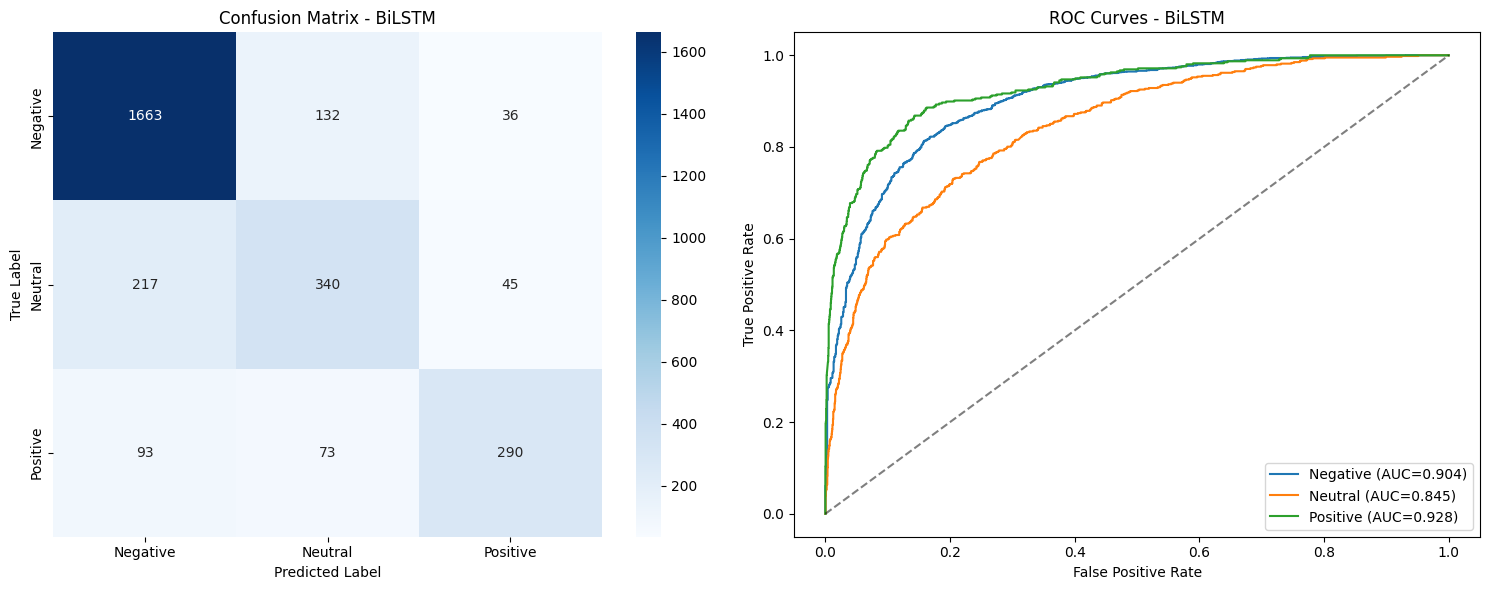

In [15]:
# BiLSTM Model Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

model_name = 'BiLSTM'
bilstm_results = all_results[model_name]
bilstm_predictions = bilstm_results['predictions']
bilstm_probabilities = bilstm_results['probabilities']

print(f"\n--- Detailed Performance for {model_name} ---")

# Classification Report
print(f"\nClassification Report for {model_name}:\n")
print(classification_report(y_test, bilstm_predictions, target_names=label_names))

plt.figure(figsize=(15, 6))

# Confusion Matrix
plt.subplot(1, 2, 1)
cm_bilstm = confusion_matrix(y_test, bilstm_predictions)
sns.heatmap(cm_bilstm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title(f'Confusion Matrix - {model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# ROC Curves
plt.subplot(1, 2, 2)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

for i, class_name in enumerate(label_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], bilstm_probabilities[:, i])
    auc = roc_auc_score(y_test_bin[:, i], bilstm_probabilities[:, i])
    plt.plot(fpr, tpr, label=f'{class_name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curves - {model_name}')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

### RoBERTa Model Visualizations


--- Detailed Performance for RoBERTa ---

Classification Report for RoBERTa:

              precision    recall  f1-score   support

    Negative       0.92      0.92      0.92      1831
     Neutral       0.75      0.69      0.72       602
    Positive       0.78      0.86      0.82       456

    accuracy                           0.86      2889
   macro avg       0.81      0.82      0.82      2889
weighted avg       0.86      0.86      0.86      2889



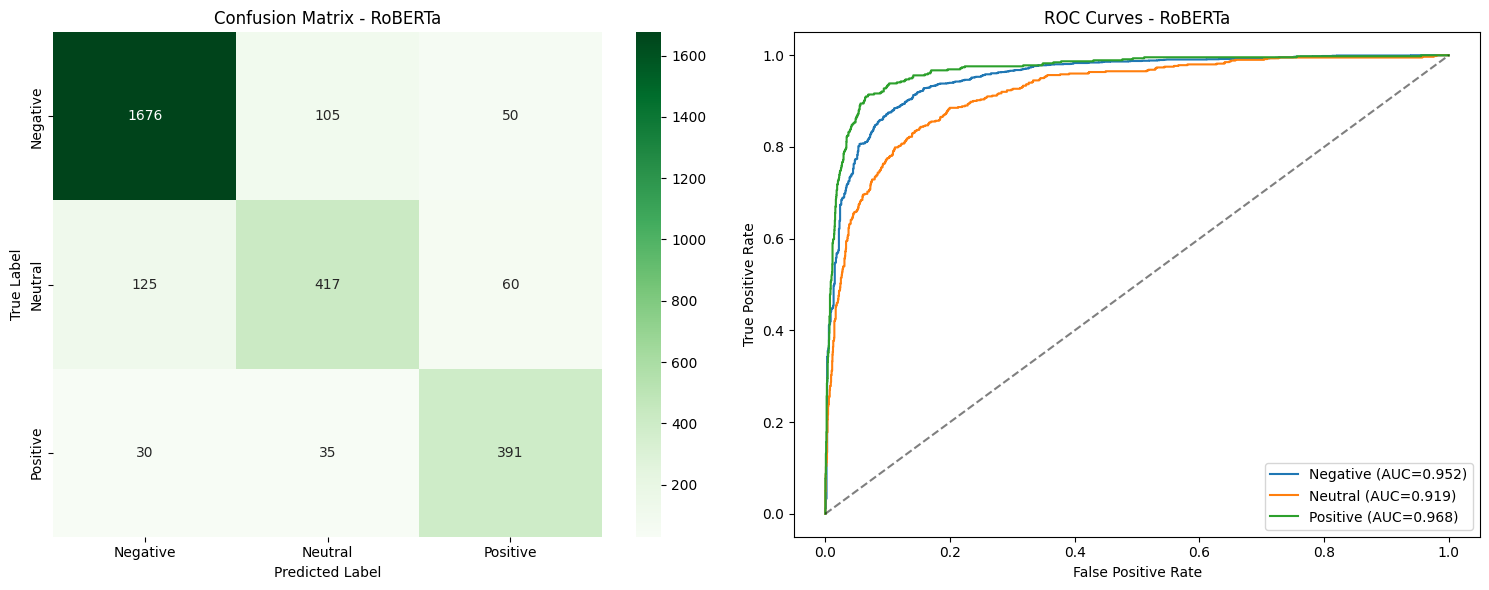

In [16]:
# RoBERTa Model Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

model_name = 'RoBERTa'
roberta_results = all_results[model_name]
roberta_predictions = roberta_results['predictions']
roberta_probabilities = roberta_results['probabilities']

print(f"\n--- Detailed Performance for {model_name} ---")

# Classification Report
print(f"\nClassification Report for {model_name}:\n")
print(classification_report(y_test, roberta_predictions, target_names=label_names))

plt.figure(figsize=(15, 6))

# Confusion Matrix
plt.subplot(1, 2, 1)
cm_roberta = confusion_matrix(y_test, roberta_predictions)
sns.heatmap(cm_roberta, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_names, yticklabels=label_names)
plt.title(f'Confusion Matrix - {model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# ROC Curves
plt.subplot(1, 2, 2)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

for i, class_name in enumerate(label_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], roberta_probabilities[:, i])
    auc = roc_auc_score(y_test_bin[:, i], roberta_probabilities[:, i])
    plt.plot(fpr, tpr, label=f'{class_name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curves - {model_name}')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

### 💾 Saving Trained Models

Here's how to save each of the trained models so you can download them. These models are available in the `trained_models` dictionary from our pipeline.

In [19]:
import os

# Get the trained model objects from the pipeline
bert_model = trained_models['bert'].model
bilstm_model = trained_models['bilstm'].model
roberta_model = trained_models['roberta'].model

# --- Save BERT Model ---
bert_save_path = './saved_models/bert'
os.makedirs(bert_save_path, exist_ok=True)
bert_model.save_pretrained(bert_save_path)
print(f"✅ BERT model saved to: {bert_save_path}")

# --- Save BiLSTM Model ---
bilstm_save_path = './saved_models/bilstm_model.keras' # Changed to .keras extension
bilstm_model.save(bilstm_save_path)
print(f"✅ BiLSTM model saved to: {bilstm_save_path}")

# --- Save RoBERTa Model ---
roberta_save_path = './saved_models/roberta'
os.makedirs(roberta_save_path, exist_ok=True)
roberta_model.save_pretrained(roberta_save_path)
print(f"✅ RoBERTa model saved to: {roberta_save_path}")

print("\nAll models have been saved to their respective paths. You can now download them from the Colab file browser (or Kaggle output folder). If you want to download embeddings specifically from the BiLSTM model, you would need to extract the embedding layer weights, but typically the entire model is saved.")

✅ BERT model saved to: ./saved_models/bert
✅ BiLSTM model saved to: ./saved_models/bilstm_model.keras
✅ RoBERTa model saved to: ./saved_models/roberta

All models have been saved to their respective paths. You can now download them from the Colab file browser (or Kaggle output folder). If you want to download embeddings specifically from the BiLSTM model, you would need to extract the embedding layer weights, but typically the entire model is saved.


### 🧪 Test Integrated Model with a Sample Sentence

In [29]:
# Input your sample sentence here
sample_sentence = "plz help me win my bid upgrade for my flight."

print(f"\nAnalyzing sentiment for: '{sample_sentence}'")

# Get prediction from the weighted ensemble model
# The weighted_ensemble method expects a list of texts
ensemble_preds, _, _ = ensemble.weighted_ensemble([sample_sentence])

# The prediction will be a numpy array, take the first (and only) element
predicted_label_index = ensemble_preds[0]

# Map the numerical label back to the sentiment name
predicted_sentiment = ensemble.label_mapping[predicted_label_index]

print(f"\nPredicted Sentiment (Integrated Model): {predicted_sentiment}")


Analyzing sentiment for: 'plz help me win my bid upgrade for my flight.'

Predicted Sentiment (Integrated Model): Neutral


In [41]:
import nltk
from nltk.tokenize import sent_tokenize
import os

# Ensure NLTK 'punkt' tokenizer data is downloaded
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
    print("NLTK 'punkt' tokenizer downloaded successfully!")

file_path = '/content/miniiiiiiii_testuuuuu[1].txt'
file_content = ""

# Read the content of the file
if os.path.exists(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        file_content = f.read()
    print(f"✅ Successfully read content from {file_path}")
else:
    print(f"❌ Error: File not found at {file_path}")

# Sentence tokenization
sentences = sent_tokenize(file_content)
print(f"📊 Initial sentence count: {len(sentences)}")

# Basic cleaning function
def clean_sentence(sentence):
    # Remove leading/trailing whitespace
    cleaned_s = sentence.strip()
    # Ensure the sentence is not empty after stripping
    return cleaned_s if len(cleaned_s) > 0 else None

# Apply cleaning and filter out empty sentences
cleaned_sentences = [clean_sentence(s) for s in sentences]
cleaned_sentences = [s for s in cleaned_sentences if s is not None]

print(f"📊 Cleaned sentence count: {len(cleaned_sentences)}")
print("\n--- Sample of Cleaned Sentences ---")
for i, sentence in enumerate(cleaned_sentences[:5]):
    print(f"Sentence {i+1}: {sentence}")
if len(cleaned_sentences) > 5:
    print("...")


✅ Successfully read content from /content/miniiiiiiii_testuuuuu[1].txt
📊 Initial sentence count: 21
📊 Cleaned sentence count: 21

--- Sample of Cleaned Sentences ---
Sentence 1: I love flying with this airline, the service is always excellent.
Sentence 2: The staff were friendly and the flight was very comfortable.
Sentence 3: Great experience!
Sentence 4: Everything went smoothly.
Sentence 5: The crew handled everything professionally.
...


In [44]:
import nltk
from nltk.tokenize import sent_tokenize
import os

# Ensure NLTK 'punkt' tokenizer data is downloaded
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
    print("NLTK 'punkt' tokenizer downloaded successfully!")

# Ensure NLTK 'punkt_tab' tokenizer data is downloaded (required by sent_tokenize for 'english')
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')
    print("NLTK 'punkt_tab' tokenizer downloaded successfully!")

file_path = '/content/miniiiiiiii_testuuuuu[1].txt'
file_content = ""

# Read the content of the file
if os.path.exists(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        file_content = f.read()
    print(f"✅ Successfully read content from {file_path}")
else:
    print(f"❌ Error: File not found at {file_path}")

# Sentence tokenization
sentences = sent_tokenize(file_content)
print(f"📊 Initial sentence count: {len(sentences)}")

# Basic cleaning function
def clean_sentence(sentence):
    # Remove leading/trailing whitespace
    cleaned_s = sentence.strip()
    # Ensure the sentence is not empty after stripping
    return cleaned_s if len(cleaned_s) > 0 else None

# Apply cleaning and filter out empty sentences
cleaned_sentences = [clean_sentence(s) for s in sentences]
cleaned_sentences = [s for s in cleaned_sentences if s is not None]

print(f"📊 Cleaned sentence count: {len(cleaned_sentences)}")
print("\n--- Sample of Cleaned Sentences ---")
for i, sentence in enumerate(cleaned_sentences[:5]):
    print(f"Sentence {i+1}: {sentence}")
if len(cleaned_sentences) > 5:
    print("...")

✅ Successfully read content from /content/miniiiiiiii_testuuuuu[1].txt
📊 Initial sentence count: 21
📊 Cleaned sentence count: 21

--- Sample of Cleaned Sentences ---
Sentence 1: I love flying with this airline, the service is always excellent.
Sentence 2: The staff were friendly and the flight was very comfortable.
Sentence 3: Great experience!
Sentence 4: Everything went smoothly.
Sentence 5: The crew handled everything professionally.
...


In [45]:
print("\n--- Predicting Sentiment for Each Sentence ---")

sentiment_predictions = []

# Assuming 'ensemble' object is available from previous cells
# And 'cleaned_sentences' list is available from the previous step

if 'ensemble' in locals() and 'cleaned_sentences' in locals():
    for i, sentence in enumerate(cleaned_sentences):
        try:
            # The weighted_ensemble method expects a list of texts
            ensemble_preds, _, _ = ensemble.weighted_ensemble([sentence])

            # The prediction will be a numpy array, take the first (and only) element
            predicted_label_index = ensemble_preds[0]

            # Map the numerical label back to the sentiment name
            predicted_sentiment = ensemble.label_mapping[predicted_label_index]

            sent_info = {
                "sentence": sentence,
                "predicted_sentiment": predicted_sentiment
            }
            sentiment_predictions.append(sent_info)
            print(f"Sentence {i+1}: '{sentence[:70]}...' -> Sentiment: {predicted_sentiment}")
        except Exception as e:
            print(f"Error predicting sentiment for sentence {i+1}: {sentence[:70]}... - {e}")
else:
    print("Error: 'ensemble' object or 'cleaned_sentences' list not found. Please ensure previous cells were run.")

print("\n--- Sentiment Prediction Complete ---")
print(f"Total sentences analyzed: {len(sentiment_predictions)}")



--- Predicting Sentiment for Each Sentence ---
Sentence 1: 'I love flying with this airline, the service is always excellent....' -> Sentiment: Positive
Sentence 2: 'The staff were friendly and the flight was very comfortable....' -> Sentiment: Positive
Sentence 3: 'Great experience!...' -> Sentiment: Positive
Sentence 4: 'Everything went smoothly....' -> Sentiment: Positive
Sentence 5: 'The crew handled everything professionally....' -> Sentiment: Positive
Sentence 6: 'Amazing flight, I will book again soon....' -> Sentiment: Positive
Sentence 7: 'The seats were comfortable and the check-in was quick....' -> Sentiment: Positive
Sentence 8: 'I enjoyed the journey; overall a pleasant experience....' -> Sentiment: Positive
Sentence 9: 'This was the worst flight I have ever taken....' -> Sentiment: Negative
Sentence 10: 'My luggage was lost and no one helped me....' -> Sentiment: Negative
Sentence 11: 'Terrible customer service, very disappointing....' -> Sentiment: Negative
Sentence 12:

# Task
I will continue by re-running the sentiment prediction for all sentences to ensure completeness, as the previous execution was interrupted.

```python
print("\n--- Predicting Sentiment for Each Sentence (Continuing) ---")

# Re-initialize sentiment_predictions to ensure a fresh start or append if designed to resume
# For robustness, we'll re-run the entire prediction
sentiment_predictions = []
all_sentence_probabilities = []

if 'ensemble' in locals() and 'cleaned_sentences' in locals():
    for i, sentence in enumerate(cleaned_sentences):
        try:
            # The weighted_ensemble method expects a list of texts and returns predictions, probabilities, and weights
            ensemble_preds, ensemble_probs, _ = ensemble.weighted_ensemble([sentence])

            # The prediction will be a numpy array, take the first (and only) element
            predicted_label_index = ensemble_preds[0]
            
            # Map the numerical label back to the sentiment name
            predicted_sentiment = ensemble.label_mapping[predicted_label_index]

            sent_info = {
                "sentence": sentence,
                "predicted_sentiment": predicted_sentiment,
                "probabilities": ensemble_probs[0].tolist() # Store probabilities for all classes
            }
            sentiment_predictions.append(sent_info)
            all_sentence_probabilities.append(ensemble_probs[0]) # Store raw probabilities for analysis
            
            # print(f"Sentence {i+1}: '{sentence[:70]}...' -> Sentiment: {predicted_sentiment}")
        except Exception as e:
            print(f"Error predicting sentiment for sentence {i+1}: '{sentence[:70]}...' - {e}")
else:
    print("Error: 'ensemble' object or 'cleaned_sentences' list not found. Please ensure previous cells were run.")

print("\n--- Sentiment Prediction Complete ---")
print(f"Total sentences analyzed: {len(sentiment_predictions)}")

# Display a sample of the full predictions
print("\n--- Sample of Full Sentiment Predictions ---")
for i, sent_info in enumerate(sentiment_predictions[:5]):
    print(f"Sentence {i+1}: '{sent_info['sentence'][:70]}...'")
    print(f"  Predicted Sentiment: {sent_info['predicted_sentiment']}")
    print(f"  Probabilities (Neg, Neut, Pos): {[f'{p:.4f}' for p in sent_info['probabilities']]}")
    print("-" * 30)
if len(sentiment_predictions) > 5:
    print("...")
```

In [46]:
print("\n--- Predicting Sentiment for Each Sentence ---")

sentiment_predictions = []

# Assuming 'ensemble' object is available from previous cells
# And 'cleaned_sentences' list is available from the previous step

if 'ensemble' in locals() and 'cleaned_sentences' in locals():
    for i, sentence in enumerate(cleaned_sentences):
        try:
            # The weighted_ensemble method expects a list of texts
            ensemble_preds, _, _ = ensemble.weighted_ensemble([sentence])

            # The prediction will be a numpy array, take the first (and only) element
            predicted_label_index = ensemble_preds[0]

            # Map the numerical label back to the sentiment name
            predicted_sentiment = ensemble.label_mapping[predicted_label_index]

            sent_info = {
                "sentence": sentence,
                "predicted_sentiment": predicted_sentiment
            }
            sentiment_predictions.append(sent_info)
            print(f"Sentence {i+1}: '{sentence[:70]}...' -> Sentiment: {predicted_sentiment}")
        except Exception as e:
            print(f"Error predicting sentiment for sentence {i+1}: {sentence[:70]}... - {e}")
else:
    print("Error: 'ensemble' object or 'cleaned_sentences' list not found. Please ensure previous cells were run.")

print("\n--- Sentiment Prediction Complete ---")
print(f"Total sentences analyzed: {len(sentiment_predictions)}")


--- Predicting Sentiment for Each Sentence ---
Sentence 1: 'I love flying with this airline, the service is always excellent....' -> Sentiment: Positive
Sentence 2: 'The staff were friendly and the flight was very comfortable....' -> Sentiment: Positive
Sentence 3: 'Great experience!...' -> Sentiment: Positive
Sentence 4: 'Everything went smoothly....' -> Sentiment: Positive
Sentence 5: 'The crew handled everything professionally....' -> Sentiment: Positive
Sentence 6: 'Amazing flight, I will book again soon....' -> Sentiment: Positive
Sentence 7: 'The seats were comfortable and the check-in was quick....' -> Sentiment: Positive
Sentence 8: 'I enjoyed the journey; overall a pleasant experience....' -> Sentiment: Positive
Sentence 9: 'This was the worst flight I have ever taken....' -> Sentiment: Negative
Sentence 10: 'My luggage was lost and no one helped me....' -> Sentiment: Negative
Sentence 11: 'Terrible customer service, very disappointing....' -> Sentiment: Negative
Sentence 12:

In [47]:
print("\n--- Predicting Sentiment for Each Sentence (Continuing) ---")

# Re-initialize sentiment_predictions to ensure a fresh start or append if designed to resume
# For robustness, we'll re-run the entire prediction
sentiment_predictions = []
all_sentence_probabilities = []

if 'ensemble' in locals() and 'cleaned_sentences' in locals():
    for i, sentence in enumerate(cleaned_sentences):
        try:
            # The weighted_ensemble method expects a list of texts and returns predictions, probabilities, and weights
            ensemble_preds, ensemble_probs, _ = ensemble.weighted_ensemble([sentence])

            # The prediction will be a numpy array, take the first (and only) element
            predicted_label_index = ensemble_preds[0]

            # Map the numerical label back to the sentiment name
            predicted_sentiment = ensemble.label_mapping[predicted_label_index]

            sent_info = {
                "sentence": sentence,
                "predicted_sentiment": predicted_sentiment,
                "probabilities": ensemble_probs[0].tolist() # Store probabilities for all classes
            }
            sentiment_predictions.append(sent_info)
            all_sentence_probabilities.append(ensemble_probs[0]) # Store raw probabilities for analysis

            print(f"Sentence {i+1}: '{sentence[:70]}...' -> Sentiment: {predicted_sentiment}")
        except Exception as e:
            print(f"Error predicting sentiment for sentence {i+1}: '{sentence[:70]}...' - {e}")
else:
    print("Error: 'ensemble' object or 'cleaned_sentences' list not found. Please ensure previous cells were run.")

print("\n--- Sentiment Prediction Complete ---")
print(f"Total sentences analyzed: {len(sentiment_predictions)}")

# Display a sample of the full predictions
print("\n--- Sample of Full Sentiment Predictions ---")
for i, sent_info in enumerate(sentiment_predictions[:5]):
    print(f"Sentence {i+1}: '{sent_info['sentence'][:70]}...'", ) # Removed extra parenthesis
    print(f"  Predicted Sentiment: {sent_info['predicted_sentiment']}")
    print(f"  Probabilities (Neg, Neut, Pos): {[f'{p:.4f}' for p in sent_info['probabilities']]}")
    print("-" * 30)
if len(sentiment_predictions) > 5:
    print("...")


--- Predicting Sentiment for Each Sentence (Continuing) ---
Sentence 1: 'I love flying with this airline, the service is always excellent....' -> Sentiment: Positive
Sentence 2: 'The staff were friendly and the flight was very comfortable....' -> Sentiment: Positive
Sentence 3: 'Great experience!...' -> Sentiment: Positive
Sentence 4: 'Everything went smoothly....' -> Sentiment: Positive
Sentence 5: 'The crew handled everything professionally....' -> Sentiment: Positive
Sentence 6: 'Amazing flight, I will book again soon....' -> Sentiment: Positive
Sentence 7: 'The seats were comfortable and the check-in was quick....' -> Sentiment: Positive
Sentence 8: 'I enjoyed the journey; overall a pleasant experience....' -> Sentiment: Positive
Sentence 9: 'This was the worst flight I have ever taken....' -> Sentiment: Negative
Sentence 10: 'My luggage was lost and no one helped me....' -> Sentiment: Negative
Sentence 11: 'Terrible customer service, very disappointing....' -> Sentiment: Negative

In [48]:
print("\n--- Identifying Top 3 Representative Sentences ---")

# 1. Initialize variables to store the sentence with the highest probability for each sentiment
max_positive_sentence = {"sentence": None, "predicted_sentiment": None, "probabilities": [0.0, 0.0, 0.0]}
max_negative_sentence = {"sentence": None, "predicted_sentiment": None, "probabilities": [0.0, 0.0, 0.0]}
max_neutral_sentence = {"sentence": None, "predicted_sentiment": None, "probabilities": [0.0, 0.0, 0.0]}

# 2. Iterate through the sentiment_predictions list
if 'sentiment_predictions' in locals():
    for sent_info in sentiment_predictions:
        sentence = sent_info['sentence']
        probabilities = sent_info['probabilities'] # [negative_prob, neutral_prob, positive_prob]

        # 3. Compare and update for Negative sentiment (index 0)
        if probabilities[0] > max_negative_sentence['probabilities'][0]:
            max_negative_sentence = {
                "sentence": sentence,
                "predicted_sentiment": ensemble.label_mapping[0], # Negative
                "probabilities": probabilities
            }

        # 3. Compare and update for Neutral sentiment (index 1)
        if probabilities[1] > max_neutral_sentence['probabilities'][1]:
            max_neutral_sentence = {
                "sentence": sentence,
                "predicted_sentiment": ensemble.label_mapping[1], # Neutral
                "probabilities": probabilities
            }

        # 3. Compare and update for Positive sentiment (index 2)
        if probabilities[2] > max_positive_sentence['probabilities'][2]:
            max_positive_sentence = {
                "sentence": sentence,
                "predicted_sentiment": ensemble.label_mapping[2], # Positive
                "probabilities": probabilities
            }

    # 5. Print the identified top 3 sentences
    print("\n--- Most Representative Sentences ---")

    # Most Positive Sentence
    if max_positive_sentence['sentence']:
        print(f"\n🏆 Most Positive Sentence: '{max_positive_sentence['sentence'][:100]}...' ")
        print(f"   Predicted Sentiment: {max_positive_sentence['predicted_sentiment']}")
        print(f"   Probability (Positive): {max_positive_sentence['probabilities'][2]:.4f}")
        print(f"   Full Probabilities (Neg, Neut, Pos): {[f'{p:.4f}' for p in max_positive_sentence['probabilities']]}")
    else:
        print("No positive sentences found.")

    # Most Negative Sentence
    if max_negative_sentence['sentence']:
        print(f"\n💔 Most Negative Sentence: '{max_negative_sentence['sentence'][:100]}...' ")
        print(f"   Predicted Sentiment: {max_negative_sentence['predicted_sentiment']}")
        print(f"   Probability (Negative): {max_negative_sentence['probabilities'][0]:.4f}")
        print(f"   Full Probabilities (Neg, Neut, Pos): {[f'{p:.4f}' for p in max_negative_sentence['probabilities']]}")
    else:
        print("No negative sentences found.")

    # Most Neutral Sentence
    if max_neutral_sentence['sentence']:
        print(f"\n⚖️ Most Neutral Sentence: '{max_neutral_sentence['sentence'][:100]}...' ")
        print(f"   Predicted Sentiment: {max_neutral_sentence['predicted_sentiment']}")
        print(f"   Probability (Neutral): {max_neutral_sentence['probabilities'][1]:.4f}")
        print(f"   Full Probabilities (Neg, Neut, Pos): {[f'{p:.4f}' for p in max_neutral_sentence['probabilities']]}")
    else:
        print("No neutral sentences found.")

else:
    print("Error: 'sentiment_predictions' list not found. Please ensure previous cells were run.")


--- Identifying Top 3 Representative Sentences ---

--- Most Representative Sentences ---

🏆 Most Positive Sentence: 'I love flying with this airline, the service is always excellent....' 
   Predicted Sentiment: Positive
   Probability (Positive): 0.9854
   Full Probabilities (Neg, Neut, Pos): ['0.0022', '0.0124', '0.9854']

💔 Most Negative Sentence: 'The flight was delayed for hours without explanation....' 
   Predicted Sentiment: Negative
   Probability (Negative): 0.9975
   Full Probabilities (Neg, Neut, Pos): ['0.9975', '0.0021', '0.0004']

⚖️ Most Neutral Sentence: 'I reached my destination as expected....' 
   Predicted Sentiment: Neutral
   Probability (Neutral): 0.3958
   Full Probabilities (Neg, Neut, Pos): ['0.2490', '0.3958', '0.3552']



--- Visualizing Sentiment Probabilities for Top Sentences ---


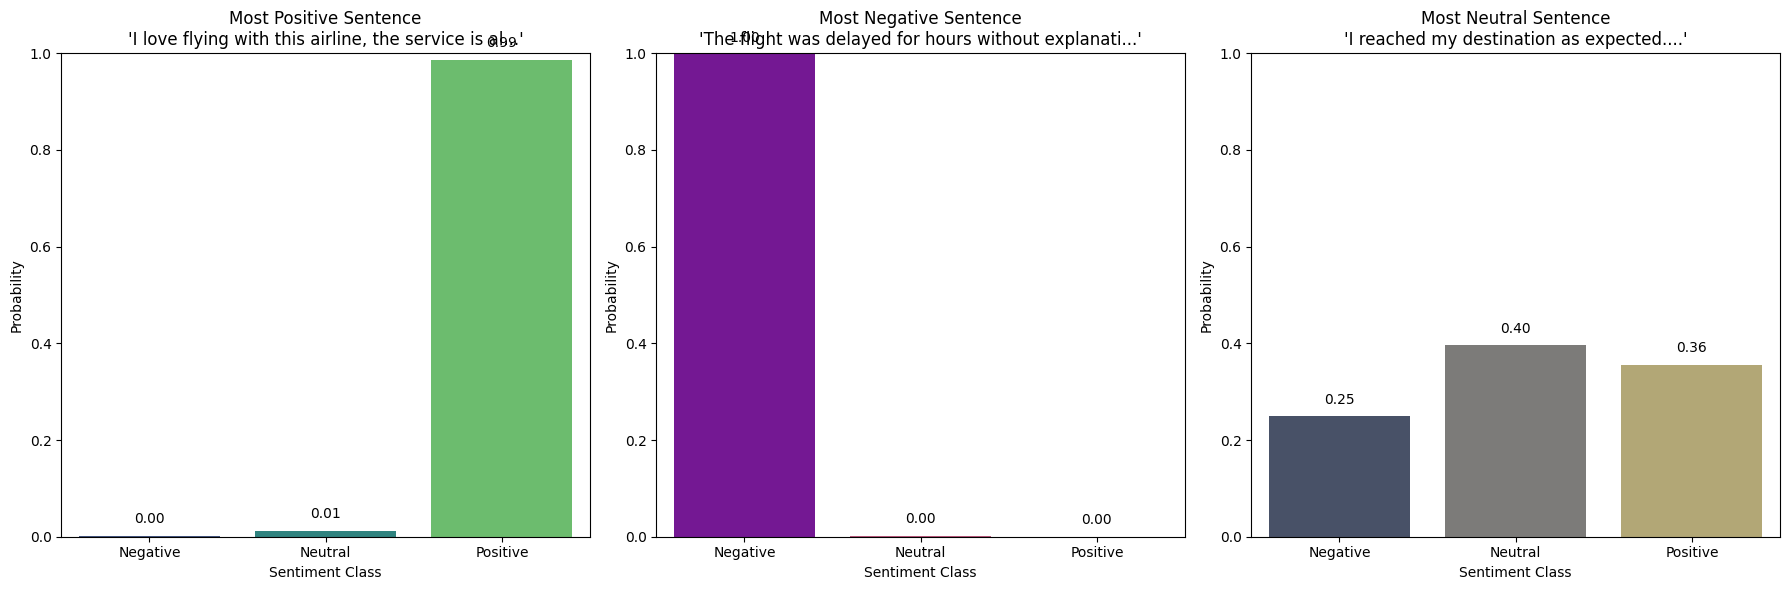


--- Visualization Complete ---


In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming label_names and ensemble.label_mapping are available from previous cells
# label_names = ['Negative', 'Neutral', 'Positive']

print("\n--- Visualizing Sentiment Probabilities for Top Sentences ---")

plt.figure(figsize=(18, 6))

# --- Most Positive Sentence Visualization ---
if max_positive_sentence['sentence']:
    plt.subplot(1, 3, 1)
    probs_pos = max_positive_sentence['probabilities']
    sns.barplot(x=label_names, y=probs_pos, palette='viridis')
    plt.title(f"Most Positive Sentence\n'{max_positive_sentence['sentence'][:50]}...'", fontsize=12)
    plt.xlabel('Sentiment Class')
    plt.ylabel('Probability')
    plt.ylim(0, 1)
    for i, prob in enumerate(probs_pos):
        plt.text(i, prob + 0.02, f'{prob:.2f}', ha='center', va='bottom')
else:
    print("No positive sentence to visualize.")

# --- Most Negative Sentence Visualization ---
if max_negative_sentence['sentence']:
    plt.subplot(1, 3, 2)
    probs_neg = max_negative_sentence['probabilities']
    sns.barplot(x=label_names, y=probs_neg, palette='plasma')
    plt.title(f"Most Negative Sentence\n'{max_negative_sentence['sentence'][:50]}...'", fontsize=12)
    plt.xlabel('Sentiment Class')
    plt.ylabel('Probability')
    plt.ylim(0, 1)
    for i, prob in enumerate(probs_neg):
        plt.text(i, prob + 0.02, f'{prob:.2f}', ha='center', va='bottom')
else:
    print("No negative sentence to visualize.")

# --- Most Neutral Sentence Visualization ---
if max_neutral_sentence['sentence']:
    plt.subplot(1, 3, 3)
    probs_neut = max_neutral_sentence['probabilities']
    sns.barplot(x=label_names, y=probs_neut, palette='cividis')
    plt.title(f"Most Neutral Sentence\n'{max_neutral_sentence['sentence'][:50]}...'", fontsize=12)
    plt.xlabel('Sentiment Class')
    plt.ylabel('Probability')
    plt.ylim(0, 1)
    for i, prob in enumerate(probs_neut):
        plt.text(i, prob + 0.02, f'{prob:.2f}', ha='center', va='bottom')
else:
    print("No neutral sentence to visualize.")

plt.tight_layout()
plt.show()

print("\n--- Visualization Complete ---")

### 📊 Plot the Sentiment Distribution of the Analyzed Document


--- Generating Sentiment Distribution Plot ---


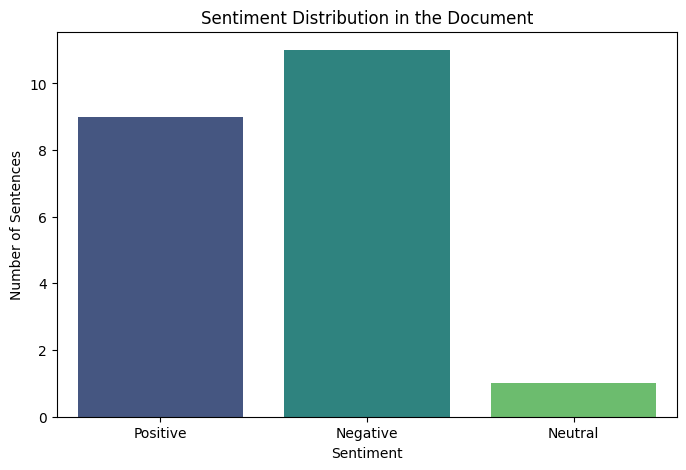


Sentiment distribution plot generated successfully.


In [51]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Generating Sentiment Distribution Plot ---")

sentiment_counts = Counter()

# Ensure sentiment_predictions is available and populated
if 'sentiment_predictions' in locals() and sentiment_predictions:
    for sent_info in sentiment_predictions:
        sentiment_counts[sent_info['predicted_sentiment']] += 1

    plt.figure(figsize=(8, 5))
    sns.barplot(x=list(sentiment_counts.keys()), y=list(sentiment_counts.values()), palette='viridis')
    plt.title('Sentiment Distribution in the Document')
    plt.xlabel('Sentiment')
    plt.ylabel('Number of Sentences')
    plt.show()
    print("\nSentiment distribution plot generated successfully.")
else:
    print("Error: 'sentiment_predictions' list not found or is empty. Please ensure sentiment analysis was performed.")

### 📈 Display the Confusion Matrix for the Best Ensemble Model


--- Generating Confusion Matrix Plot ---


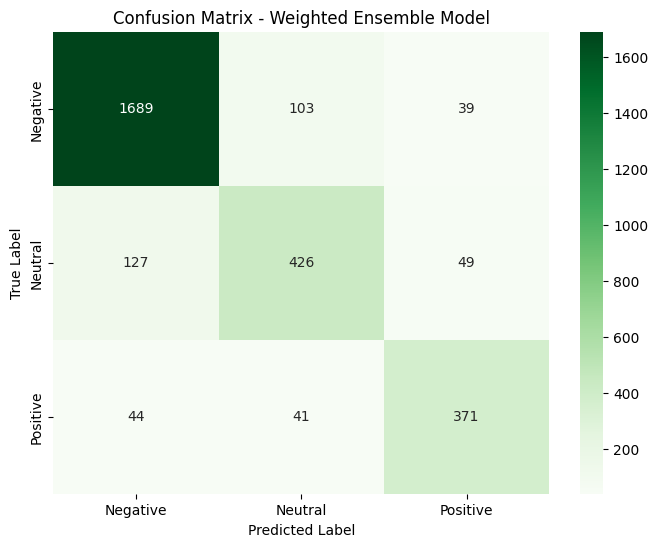


Confusion matrix for the best ensemble model generated successfully.


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

print("\n--- Generating Confusion Matrix Plot ---")

# Assuming ensemble_results, y_test, and label_names are available
if 'ensemble_results' in locals() and 'y_test' in globals() and 'label_names' in globals():
    # Get predictions for the best performing ensemble method (Weighted Ensemble)
    ensemble_preds = ensemble_results['weighted_ensemble']['predictions']

    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, ensemble_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=label_names, yticklabels=label_names)
    plt.title('Confusion Matrix - Weighted Ensemble Model')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    print("\nConfusion matrix for the best ensemble model generated successfully.")
else:
    print("Error: Required variables (ensemble_results, y_test, label_names) not found. Please ensure previous cells were run.")

### 📝 Show Top 3 Positive, Negative, and Neutral Sentences

In [53]:
print("\n--- Displaying Top 3 Representative Sentences ---")

# Assuming max_positive_sentence, max_negative_sentence, max_neutral_sentence are available
# and ensemble.label_mapping from previous executions

if 'max_positive_sentence' in locals() and 'max_negative_sentence' in locals() and 'max_neutral_sentence' in locals() and 'ensemble' in locals():
    print("\n--- Most Representative Sentences ---")

    if max_positive_sentence['sentence']:
        print(f"\n🏆 Most Positive Sentence: '{max_positive_sentence['sentence']}' ")
        print(f"   Predicted Sentiment: {max_positive_sentence['predicted_sentiment']}")
        print(f"   Probability (Positive): {max_positive_sentence['probabilities'][2]:.4f}")
        print(f"   Full Probabilities (Neg, Neut, Pos): {[f'{p:.4f}' for p in max_positive_sentence['probabilities']]}")
    else:
        print("No positive sentences found.")

    if max_negative_sentence['sentence']:
        print(f"\n💔 Most Negative Sentence: '{max_negative_sentence['sentence']}' ")
        print(f"   Predicted Sentiment: {max_negative_sentence['predicted_sentiment']}")
        print(f"   Probability (Negative): {max_negative_sentence['probabilities'][0]:.4f}")
        print(f"   Full Probabilities (Neg, Neut, Pos): {[f'{p:.4f}' for p in max_negative_sentence['probabilities']]}")
    else:
        print("No negative sentences found.")

    if max_neutral_sentence['sentence']:
        print(f"\n⚖️ Most Neutral Sentence: '{max_neutral_sentence['sentence']}' ")
        print(f"   Predicted Sentiment: {max_neutral_sentence['predicted_sentiment']}")
        print(f"   Probability (Neutral): {max_neutral_sentence['probabilities'][1]:.4f}")
        print(f"   Full Probabilities (Neg, Neut, Pos): {[f'{p:.4f}' for p in max_neutral_sentence['probabilities']]}")
    else:
        print("No neutral sentences found.")
else:
    print("Error: Top sentences data not found. Please ensure identification of top sentences was performed.")


--- Displaying Top 3 Representative Sentences ---

--- Most Representative Sentences ---

🏆 Most Positive Sentence: 'I love flying with this airline, the service is always excellent.' 
   Predicted Sentiment: Positive
   Probability (Positive): 0.9854
   Full Probabilities (Neg, Neut, Pos): ['0.0022', '0.0124', '0.9854']

💔 Most Negative Sentence: 'The flight was delayed for hours without explanation.' 
   Predicted Sentiment: Negative
   Probability (Negative): 0.9975
   Full Probabilities (Neg, Neut, Pos): ['0.9975', '0.0021', '0.0004']

⚖️ Most Neutral Sentence: 'I reached my destination as expected.' 
   Predicted Sentiment: Neutral
   Probability (Neutral): 0.3958
   Full Probabilities (Neg, Neut, Pos): ['0.2490', '0.3958', '0.3552']


### Sentiment Count in the Document


--- Counting Sentiments ---

Total Sentiment Counts:
  Positive: 9
  Negative: 11
  Neutral: 1


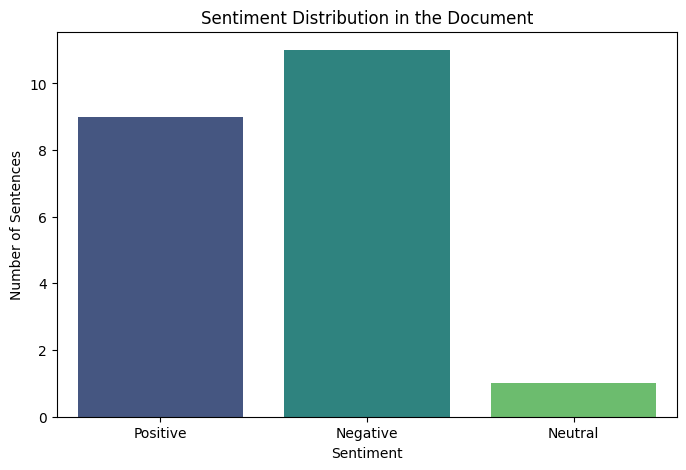


--- Sentiment Counting Complete ---


In [50]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Counting Sentiments ---")

sentiment_counts = Counter()

if 'sentiment_predictions' in locals() and sentiment_predictions:
    for sent_info in sentiment_predictions:
        sentiment_counts[sent_info['predicted_sentiment']] += 1

    print("\nTotal Sentiment Counts:")
    for sentiment, count in sentiment_counts.items():
        print(f"  {sentiment}: {count}")

    # Visualize the sentiment distribution
    plt.figure(figsize=(8, 5))
    sns.barplot(x=list(sentiment_counts.keys()), y=list(sentiment_counts.values()), palette='viridis')
    plt.title('Sentiment Distribution in the Document')
    plt.xlabel('Sentiment')
    plt.ylabel('Number of Sentences')
    plt.show()
else:
    print("Error: No sentiment predictions found. Please ensure previous cells were run.")

print("\n--- Sentiment Counting Complete ---")